# 05 - Paper Visuals

**Purpose:** Single canonical source for all project visualizations. Generates and renders
all paper-ready figures and diagnostic plots, following a clean, publication-grade template
(`theme_paper()`) and Okabe-Ito color conventions.

**Organization:** Sections mirror the paper structure:
- Section 2: Data & Weighting
- Section 3: Propensity Model
- Section 5: Modeling Results
- Section 6: FGOE & Player Evaluations
- Section 7: Field Goal Kicking Trends


In [1]:
# ============================================================
# 1. Parameters & Directory Setup & Clean
# ============================================================
get_project_root <- function() {
  cwd <- getwd()
  if (basename(cwd) %in% c('notebooks', 'Reference', 'archive')) {
    return(dirname(cwd))
  } else if (basename(dirname(cwd)) == 'notebooks') {
    return(dirname(dirname(cwd)))
  } else {
    if (dir.exists(file.path(cwd, 'notebooks'))) {
      return(cwd)
    } else {
      return(sub('[/\\\\][^/\\\\]*$', '', cwd))
    }
  }
}
PROJECT_ROOT <- get_project_root()

data_dir          <- file.path(PROJECT_ROOT, 'data')
models_dir        <- file.path(PROJECT_ROOT, 'models')
final_models_dir  <- file.path(models_dir, 'final_models')
reports_dir       <- file.path(PROJECT_ROOT, 'reports')
figures_dir       <- file.path(reports_dir, 'figures')

EVAL_SEASON_MIN   <- 2015L
EVAL_SEASON_MAX   <- 2025L
MODEL_FILE_M2_POP <- 'xfg_m2_ipw_no_kicker_season_logit.rds'
MIN_FGOE_ATT      <- 25L

# Clear existing figures first.
# Only PNGs are removed: notebook 04 writes its metrics CSVs (metrics_table.csv,
# metrics_by_era_oos.csv, m1_vs_m2_by_era_oos.csv) into this same directory, and
# a blanket unlink() of figures_dir/* silently destroyed them whenever 05 ran
# after 04 -- which is the documented notebook order.
if (dir.exists(figures_dir)) {
  old_pngs <- list.files(figures_dir, pattern = '[.]png$', full.names = TRUE)
  unlink(old_pngs)
  message('Cleared ', length(old_pngs), ' old figures from: ', figures_dir)
} else {
  dir.create(figures_dir, recursive = TRUE)
}


Cleared 31 old figures from: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures



In [2]:
# ============================================================
# 2. Imports and Custom Theme
# ============================================================
dependencies <- c(
  'dplyr', 'tibble', 'tidyr', 'readr', 'stringr', 'purrr',
  'ggplot2', 'ggrepel', 'scales', 'patchwork', 'pROC', 'glmmTMB'
)
installed <- rownames(installed.packages())
for (pkg in dependencies) {
  if (!pkg %in% installed) install.packages(pkg)
  suppressPackageStartupMessages(library(pkg, character.only = TRUE))
}

# Minimal clean theme template
theme_paper <- function(base_size = 11) {
  ggplot2::theme_minimal(base_size = base_size) +
    ggplot2::theme(
      panel.grid.major = ggplot2::element_blank(),
      panel.grid.minor = ggplot2::element_blank(),
      panel.border = ggplot2::element_rect(fill = NA, colour = 'grey80', linewidth = 0.5),
      axis.line = ggplot2::element_line(colour = 'grey45', linewidth = 0.3),
      strip.background = ggplot2::element_rect(fill = 'grey95', colour = 'grey80', linewidth = 0.4),
      strip.text = ggplot2::element_text(face = 'bold', colour = 'grey25'),
      legend.position = 'bottom',
      legend.key = ggplot2::element_blank(),
      plot.title = ggplot2::element_text(face = 'bold', size = base_size + 2),
      plot.subtitle = ggplot2::element_text(colour = 'grey35', size = base_size),
      axis.title = ggplot2::element_text(size = base_size)
    )
}

save_fig <- function(p, fname, w = 9.0, h = 5.5, dpi = 300) {
  path <- file.path(figures_dir, fname)
  ggplot2::ggsave(path, plot = p, width = w, height = h, dpi = dpi)
  message('Saved: ', path)
  invisible(path)
}

brier   <- function(y, p) mean((y - p)^2, na.rm = TRUE)
logloss <- function(y, p, eps = 1e-15) {
  -mean(y * log(pmin(pmax(p, eps), 1-eps)) + (1-y) * log(1-pmin(pmax(p, eps), 1-eps)), na.rm=TRUE)
}
auc_fn  <- function(y, p) {
  keep <- is.finite(p) & is.finite(y)
  if (sum(keep) < 2 || length(unique(y[keep])) < 2) return(NA_real_)
  as.numeric(pROC::auc(y[keep], p[keep], quiet = TRUE))
}
calc_metrics <- function(y, p, set_name) {
  tibble::tibble(
    model = set_name, n = sum(!is.na(y) & !is.na(p)),
    brier = brier(y, p), logloss = logloss(y, p), auc = auc_fn(y, p)
  )
}
calc_metrics_subset <- function(data, subset_name) {
  data %>%
    dplyr::select(kick_made, M1_Baseline, M2_IPW, M3_Augmented) %>%
    tidyr::pivot_longer(
      cols = c(M1_Baseline, M2_IPW, M3_Augmented),
      names_to = 'Model',
      values_to = 'Prob'
    ) %>%
    dplyr::mutate(Outcome_Label = ifelse(kick_made == 1, 'Make (y=1)', 'Miss (y=0)')) %>%
    dplyr::group_by(Model, Outcome_Label) %>%
    dplyr::summarise(
      Mean_Prob = mean(Prob),
      Brier = mean((kick_made - Prob)^2),
      .groups = 'drop'
    ) %>%
    dplyr::mutate(Subset = subset_name)
}
calib_data <- function(y, p, nbins = 10, label = '') {
  df <- tibble::tibble(y = y, p = p) %>% filter(!is.na(y), !is.na(p))
  df$bin <- ggplot2::cut_number(df$p, nbins)
  df %>% group_by(bin) %>%
    summarise(obs = mean(y), pred = mean(p), n = n(), .groups = 'drop') %>%
    mutate(model = label)
}
predict_safe <- function(fit, newdata) {
  if (is.null(fit)) return(rep(NA_real_, nrow(newdata)))
  p_resp <- tryCatch(as.numeric(stats::predict(fit, newdata = newdata, type = "response", allow.new.levels = TRUE)), error = function(e) NULL)
  if (!is.null(p_resp)) return(pmin(pmax(p_resp, 0), 1))
  rep(NA_real_, nrow(newdata))
}

# Color palettes
model_cols <- c('M0' = '#525252', 'M1' = '#0072B2', 'M2' = '#D55E00', 'M3' = '#009E73')
model_cols_3 <- c('M1' = '#0072B2', 'M2' = '#D55E00', 'M3' = '#009E73')
# Model colours are fixed project-wide so a given model reads the same in every
# figure: M0 grey, M1 blue, M2 orange, M3 green (Okabe-Ito, colour-blind safe).
cols_okabe_3 <- c("M1_Baseline" = "#0072B2", "M2_IPW" = "#D55E00", "M3_Augmented" = "#009E73")
cols_okabe_4 <- c("M0_Distance" = "grey", "M1_Baseline" = "#0072B2", "M2_IPW" = "#D55E00", "M3_Augmented" = "#009E73")
weight_cols <- c("Standard Weight (<=1.0)" = "#0072B2", "High Weight (>1.0)" = "#D55E00")
decision_cols <- c('FG' = '#0072B2', 'Punt' = '#525252', 'Go for It' = '#D55E00',
                   'Field Goal' = '#0072B2', 'go_for_it' = '#D55E00', 'punt' = '#525252')


In [3]:
# ============================================================
# 3. Load & Process Data
# ============================================================
preds   <- readr::read_csv(file.path(reports_dir, 'xfg_success','fg_full_with_predictions.csv'),
                            show_col_types = FALSE)
fg_all   <- readr::read_csv(file.path(data_dir, 'fg_all.csv'), show_col_types = FALSE)
preds_pi <- readr::read_csv(file.path(reports_dir, 'attempt_pi', 'attempt_pi_oof_predictions_final.csv'),
                             show_col_types = FALSE) %>%
  left_join(
    fg_all %>% select(season, game_id, play_id, kick_distance, game_seconds_remaining),
    by = c("season", "game_id", "play_id")
  )
m2_pop   <- readRDS(file.path(final_models_dir, MODEL_FILE_M2_POP))

# Test set split mapping
test_game_ids_file <- file.path(data_dir, 'augmented',
  sprintf('test_fg_game_ids_%d_%d.csv', EVAL_SEASON_MIN, EVAL_SEASON_MAX))
test_game_ids <- readr::read_csv(test_game_ids_file, show_col_types = FALSE)$game_id

preds <- preds %>%
  mutate(
    split    = if_else(game_id %in% test_game_ids, 'test', 'train'),
    fgoe_m1  = kick_made - p_m1,
    fgoe_m2  = kick_made - p_m2,
    fgoe_m3  = kick_made - p_m3
  )

preds_is  <- preds
preds_test <- preds %>% filter(split == 'test')
y_is     <- preds_is$kick_made
y_test     <- preds_test$kick_made

# Apply population model predictions to isolate kicker skill
preds_is_df   <- as.data.frame(preds_is)
preds_test_df <- as.data.frame(preds_test)

preds_is$p_m2_pop  <- predict(m2_pop, newdata = preds_is_df, type = 'response', allow.new.levels = TRUE)
preds_is$fgoe_pop   <- preds_is$kick_made - preds_is$p_m2_pop

preds_test$p_m2_pop <- predict(m2_pop, newdata = preds_test_df, type = 'response', allow.new.levels = TRUE)
preds_test$fgoe_pop  <- preds_test$kick_made - preds_test$p_m2_pop

# Construct fg_full_pooled to replicate archived 08 plots
fg_full_pooled <- preds_is %>%
  dplyr::rename(
    pred_m0_full = p_m0_full,
    pred_m1_full = p_m1_full,
    pred_m2_full = p_m2_full,
    pred_m3_full = p_m3_full
  )

# Construct decision data frame (Multi-Class 4th Down Decisions)
decision <- fg_all %>%
  filter(
    is_pat == 0L,
    play_type_original %in% c('field_goal', 'pass', 'run', 'punt'),
    !is.na(ydstogo), ydstogo >= 1
  ) %>%
  mutate(
    action = dplyr::case_when(
      play_type_original == 'field_goal' ~ 'FG',
      play_type_original == 'punt'       ~ 'punt',
      TRUE                               ~ 'go_for_it'
    )
  )
message('Data loaded. Training rows: ', nrow(preds_is), ' | Test rows: ', nrow(preds_test))


Data loaded. Training rows: 11548 | Test rows: 2251



## Section 2: Data & Weighting


Warning message:
"Removed 19 rows containing non-finite outside the scale range
(`stat_smooth()`)."


Warning message:
"Removed 19 rows containing missing values or values outside the scale range
(`geom_point()`)."


Warning message:
"Removed 19 rows containing non-finite outside the scale range
(`stat_smooth()`)."


Warning message:
"Removed 19 rows containing missing values or values outside the scale range
(`geom_point()`)."


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/weights_vs_distance.png



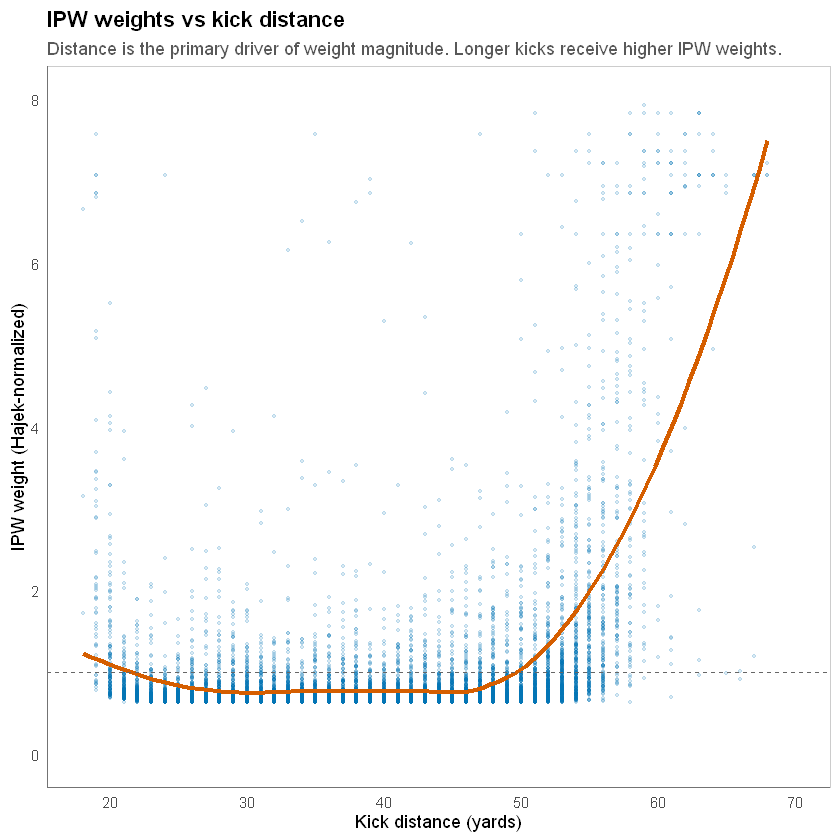

In [4]:
# --- IPW weights vs kick distance ---
p_wvsdist <- preds %>%
  filter(!is.na(w_ipw_final), is.finite(w_ipw_final)) %>%
  ggplot(aes(kick_distance, w_ipw_final)) +
  geom_point(alpha = 0.15, size = 0.7, colour = '#0072B2') +
  geom_smooth(method = 'loess', formula = y ~ x, colour = '#D55E00', se = FALSE, linewidth = 1.2) +
  geom_hline(yintercept = 1, lty = 2, colour = 'grey40') +
  scale_y_continuous(limits = c(0, 8)) +
  labs(title = 'IPW weights vs kick distance',
       subtitle = 'Distance is the primary driver of weight magnitude. Longer kicks receive higher IPW weights.',
       x = 'Kick distance (yards)', y = 'IPW weight (Hajek-normalized)') +
  theme_paper()
print(p_wvsdist)
save_fig(p_wvsdist, 'weights_vs_distance.png')


## Section 3: Attempt Propensity Model


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/propensity_density_by_decision.png



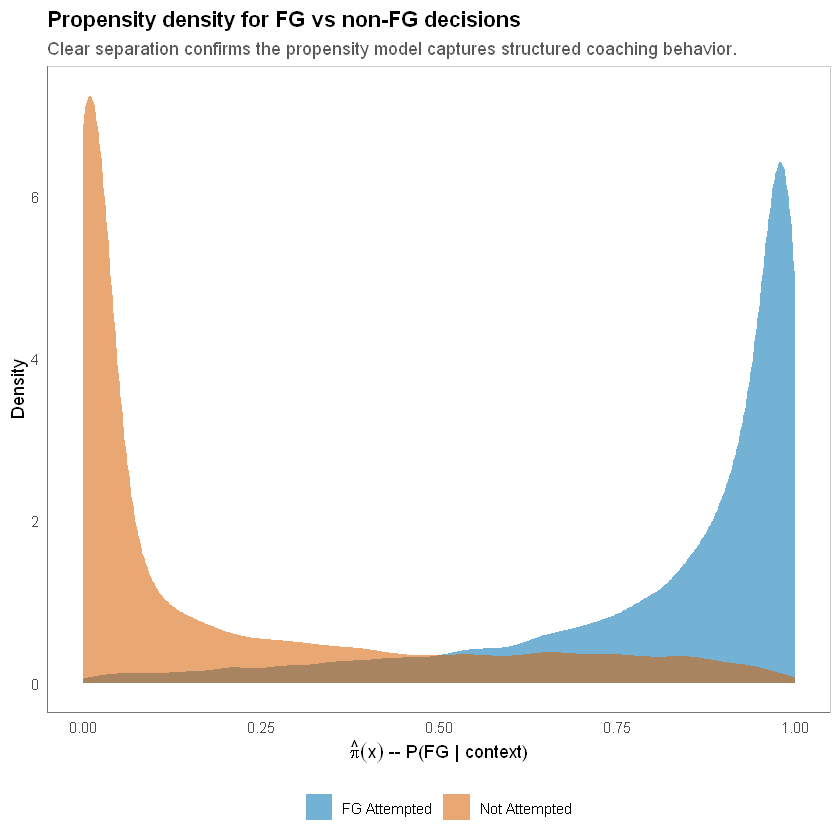

In [5]:
# --- Propensity density for FG vs non-FG decisions ---
rationality_df <- preds_pi %>%
  filter(!is.na(p_hat_multinom)) %>%
  mutate(decision_type = if_else(attempt_fg == 1, 'FG Attempted', 'Not Attempted'))

p_rat <- ggplot(rationality_df, aes(p_hat_multinom, fill = decision_type)) +
  geom_density(alpha = 0.55, colour = NA) +
  scale_fill_manual(values = c('FG Attempted' = '#0072B2', 'Not Attempted' = '#D55E00')) +
  labs(title = 'Propensity density for FG vs non-FG decisions',
    subtitle = 'Clear separation confirms the propensity model captures structured coaching behavior.',
    x = expression(hat(pi)(x) * ' -- P(FG | context)'),
    y = 'Density', fill = NULL) +
  theme_paper()
print(p_rat)
save_fig(p_rat, 'propensity_density_by_decision.png')


Warning message:
"Removed 358 rows containing non-finite outside the scale range
(`stat_density()`)."


Warning message:
"Removed 358 rows containing non-finite outside the scale range
(`stat_density()`)."


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/weight_density_by_decision.png



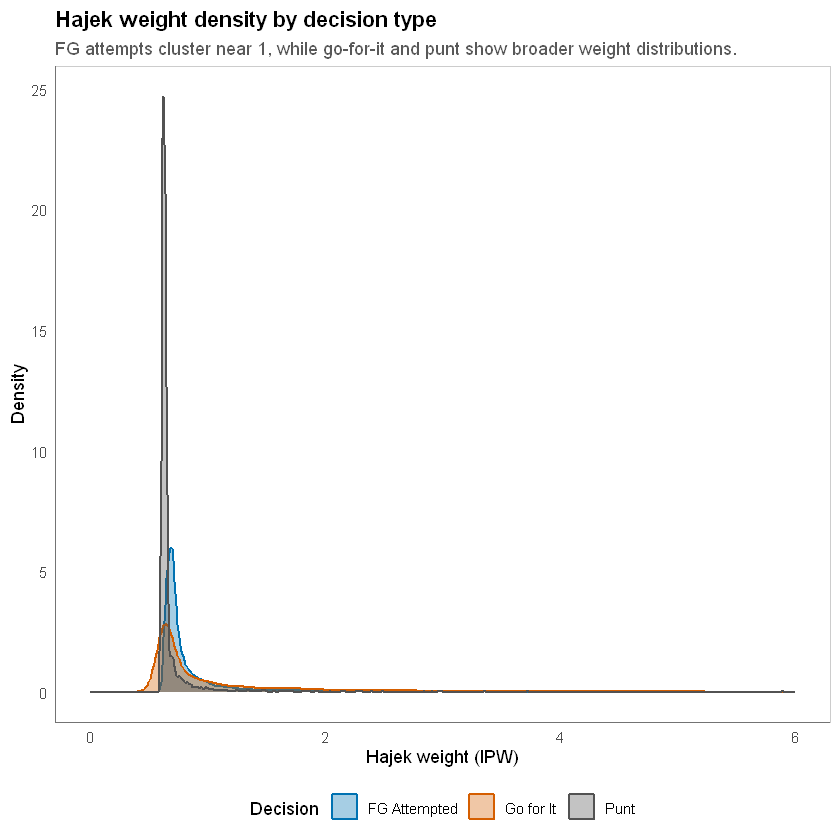

In [6]:
# --- Hajek weight density by decision type (Overlaid) ---
weight_density_df <- preds_pi %>%
  dplyr::select(action_actual, w_ipw_final) %>%
  dplyr::filter(!is.na(w_ipw_final), is.finite(w_ipw_final)) %>%
  dplyr::mutate(Decision = dplyr::recode(action_actual,
    FG = 'FG Attempted', punt = 'Punt', go_for_it = 'Go for It'))

p_weight_density <- ggplot(weight_density_df, aes(x = w_ipw_final, fill = Decision, colour = Decision)) +
  geom_density(alpha = 0.35, linewidth = 0.8) +
  scale_fill_manual(values = c('FG Attempted' = '#0072B2', 'Punt' = '#525252', 'Go for It' = '#D55E00')) +
  scale_colour_manual(values = c('FG Attempted' = '#0072B2', 'Punt' = '#525252', 'Go for It' = '#D55E00')) +
  scale_x_continuous(limits = c(0, 6)) +
  labs(title = 'Hajek weight density by decision type',
       subtitle = 'FG attempts cluster near 1, while go-for-it and punt show broader weight distributions.',
       x = 'Hajek weight (IPW)', y = 'Density',
       fill = 'Decision', colour = 'Decision') +
  theme_paper()
print(p_weight_density)
save_fig(p_weight_density, 'weight_density_by_decision.png')


## Section 5: Modeling Results


Warning message:
"Removed 501 rows containing non-finite outside the scale range (`stat_bin()`)."


Warning message:
"Removed 8 rows containing missing values or values outside the scale range
(`geom_bar()`)."


Warning message:
"Removed 501 rows containing non-finite outside the scale range (`stat_bin()`)."


Warning message:
"Removed 8 rows containing missing values or values outside the scale range
(`geom_bar()`)."


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/calibration_curves.png



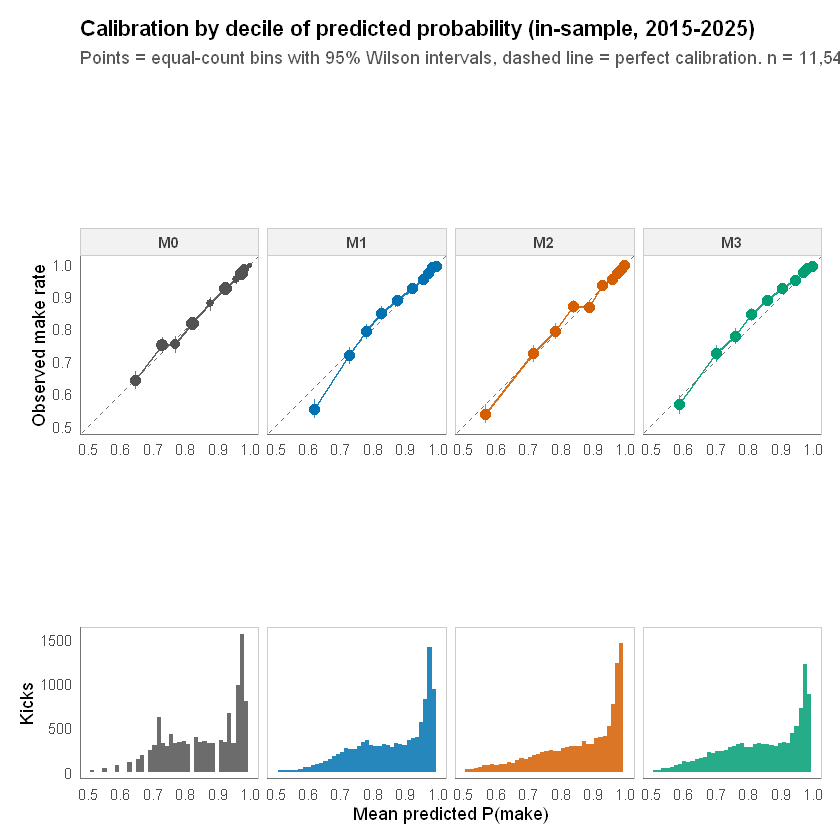

In [7]:
# --- Calibration Curves (In-Sample) — redesigned for legibility ---
# Reviewer: "Can you show a calibration plot so we can see how close to the
# diagonal predicted probabilities are?"
#
# Design notes (the previous line-only version was hard to read):
#   * equal-count (decile) bins, so every plotted point carries equal weight
#   * Wilson binomial CIs, so a point sitting off the diagonal can be judged
#     against its own sampling error instead of read as a real miscalibration
#   * one panel per model rather than four overlaid lines
#   * axes cropped to the region where predictions actually live -- FG make
#     probabilities are heavily concentrated above 0.5, so a full 0-1 square
#     spends most of its area on empty space
#   * a predicted-probability histogram under each panel, so the reader can see
#     how much probability mass sits in each part of the curve

wilson_ci <- function(k, n, z = 1.96) {
  p <- k / n; d <- 1 + z^2 / n
  ctr <- (p + z^2 / (2 * n)) / d
  hw  <- z * sqrt(p * (1 - p) / n + z^2 / (4 * n^2)) / d
  tibble::tibble(lo = pmax(0, ctr - hw), hi = pmin(1, ctr + hw))
}

calib_binned <- function(y, p, label, nbins = 10) {
  df <- tibble::tibble(y = y, p = p) %>% dplyr::filter(!is.na(y), !is.na(p))
  df$bin <- ggplot2::cut_number(df$p, nbins)
  df %>%
    dplyr::group_by(bin) %>%
    dplyr::summarise(obs = mean(y), pred = mean(p), n = dplyr::n(),
                     k = sum(y), .groups = 'drop') %>%
    dplyr::bind_cols(wilson_ci(.$k, .$n)) %>%
    dplyr::mutate(model = label)
}

build_calibration_fig <- function(pred_list, y, title, subtitle) {
  calib <- purrr::imap_dfr(pred_list, ~ calib_binned(y, .x, .y))
  long  <- purrr::imap_dfr(pred_list, ~ tibble::tibble(p = .x, model = .y)) %>%
    dplyr::filter(!is.na(p))

  rng <- range(c(calib$pred, calib$obs, calib$lo, calib$hi), na.rm = TRUE)
  rng <- c(floor(rng[1] * 20) / 20, ceiling(rng[2] * 20) / 20)

  p_top <- ggplot(calib, aes(pred, obs, colour = model)) +
    geom_abline(slope = 1, intercept = 0, lty = 2, colour = 'grey45') +
    geom_errorbar(aes(ymin = lo, ymax = hi), width = 0, linewidth = 0.5, alpha = 0.8) +
    geom_line(linewidth = 0.7, alpha = 0.9) +
    geom_point(aes(size = n)) +
    scale_size_continuous(range = c(1.2, 3.4), guide = 'none') +
    scale_colour_manual(values = model_cols, guide = 'none') +
    scale_x_continuous(limits = rng, breaks = scales::pretty_breaks(4)) +
    scale_y_continuous(limits = rng, breaks = scales::pretty_breaks(4)) +
    coord_equal() +
    facet_wrap(~ model, nrow = 1) +
    labs(title = title, subtitle = subtitle,
         x = NULL, y = 'Observed make rate') +
    theme_paper()

  p_bot <- ggplot(long, aes(p, fill = model)) +
    geom_histogram(bins = 40, colour = NA, alpha = 0.85) +
    scale_fill_manual(values = model_cols, guide = 'none') +
    scale_x_continuous(limits = rng, breaks = scales::pretty_breaks(4)) +
    facet_wrap(~ model, nrow = 1) +
    labs(x = 'Mean predicted P(make)', y = 'Kicks') +
    theme_paper() +
    theme(strip.text = element_blank(), strip.background = element_blank())

  p_top / p_bot + patchwork::plot_layout(heights = c(3.2, 1))
}

p_calib <- build_calibration_fig(
  list(M0 = preds_is$p_m0_full, M1 = preds_is$p_m1_full,
       M2 = preds_is$p_m2_full, M3 = preds_is$p_m3_full),
  y_is,
  'Calibration by decile of predicted probability (in-sample, 2015-2025)',
  paste0('Points = equal-count bins with 95% Wilson intervals, dashed line = perfect calibration. n = ',
         format(sum(!is.na(y_is)), big.mark = ','))
)
print(p_calib)
save_fig(p_calib, 'calibration_curves.png', w = 11, h = 5.2)


Warning message:
"Removed 154 rows containing non-finite outside the scale range (`stat_bin()`)."


Warning message:
"Removed 8 rows containing missing values or values outside the scale range
(`geom_bar()`)."


Warning message:
"Removed 154 rows containing non-finite outside the scale range (`stat_bin()`)."


Warning message:
"Removed 8 rows containing missing values or values outside the scale range
(`geom_bar()`)."


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/calibration_test.png



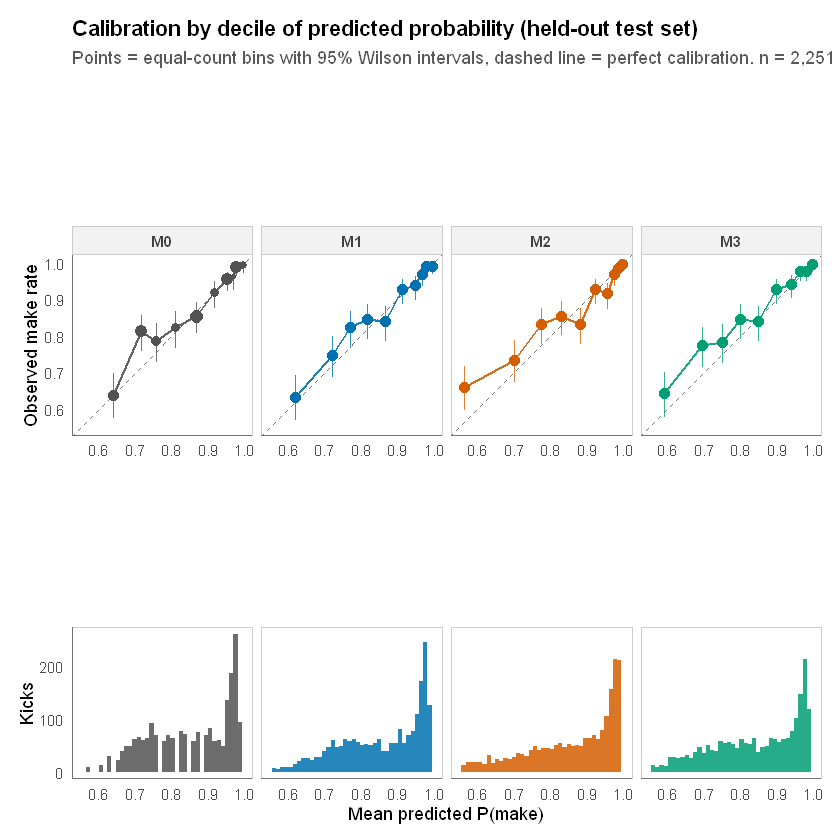

In [8]:
# --- Calibration Curves (Test Set) — same redesigned treatment ---
p_calib_test <- build_calibration_fig(
  list(M0 = preds_test$p_m0, M1 = preds_test$p_m1,
       M2 = preds_test$p_m2, M3 = preds_test$p_m3),
  y_test,
  'Calibration by decile of predicted probability (held-out test set)',
  paste0('Points = equal-count bins with 95% Wilson intervals, dashed line = perfect calibration. n = ',
         format(sum(!is.na(y_test)), big.mark = ','))
)
print(p_calib_test)
save_fig(p_calib_test, 'calibration_test.png', w = 11, h = 5.2)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/model_metrics_comparison.png



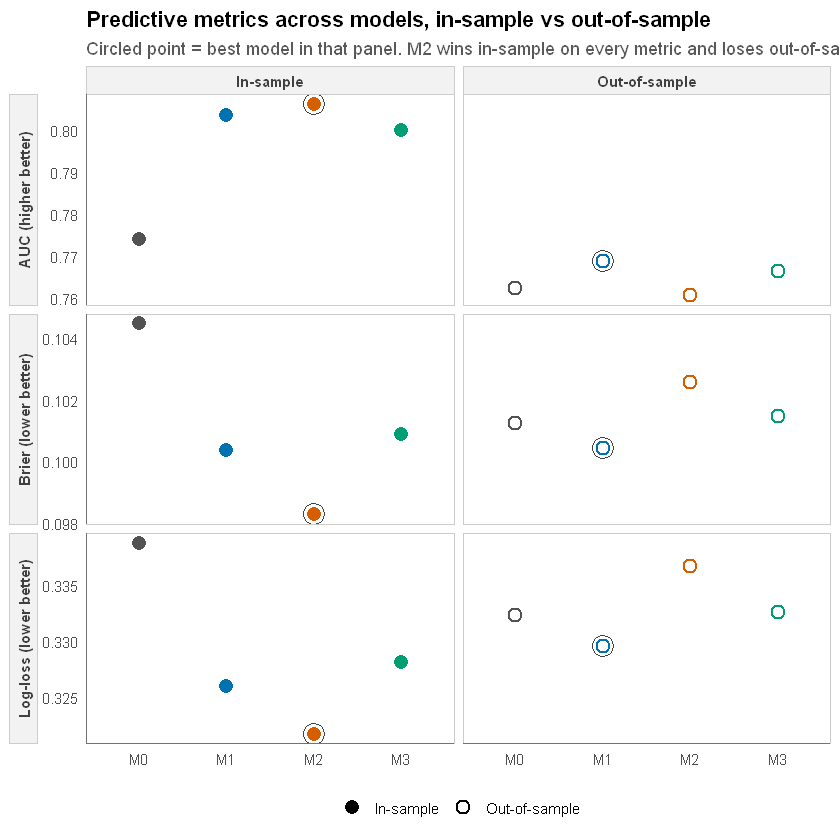

In [9]:
# --- Multi-metric model comparison (Brier / log-loss / AUC, IS vs OOS) ---
# Reviewer: "I recommend including log loss in, for example, Table 1 and other
# places." This puts all three metrics on one page so the IS-vs-OOS reversal
# (M2 wins in-sample, M1 wins out-of-sample) is visible at a glance.

metric_long <- dplyr::bind_rows(
  tibble::tibble(split = 'In-sample',
                 model = c('M0','M1','M2','M3'),
                 brier = c(brier(y_is, preds_is$p_m0_full), brier(y_is, preds_is$p_m1_full),
                           brier(y_is, preds_is$p_m2_full), brier(y_is, preds_is$p_m3_full)),
                 logloss = c(logloss(y_is, preds_is$p_m0_full), logloss(y_is, preds_is$p_m1_full),
                             logloss(y_is, preds_is$p_m2_full), logloss(y_is, preds_is$p_m3_full)),
                 auc = c(auc_fn(y_is, preds_is$p_m0_full), auc_fn(y_is, preds_is$p_m1_full),
                         auc_fn(y_is, preds_is$p_m2_full), auc_fn(y_is, preds_is$p_m3_full))),
  tibble::tibble(split = 'Out-of-sample',
                 model = c('M0','M1','M2','M3'),
                 brier = c(brier(y_test, preds_test$p_m0), brier(y_test, preds_test$p_m1),
                           brier(y_test, preds_test$p_m2), brier(y_test, preds_test$p_m3)),
                 logloss = c(logloss(y_test, preds_test$p_m0), logloss(y_test, preds_test$p_m1),
                             logloss(y_test, preds_test$p_m2), logloss(y_test, preds_test$p_m3)),
                 auc = c(auc_fn(y_test, preds_test$p_m0), auc_fn(y_test, preds_test$p_m1),
                         auc_fn(y_test, preds_test$p_m2), auc_fn(y_test, preds_test$p_m3)))
) %>%
  tidyr::pivot_longer(c(brier, logloss, auc), names_to = 'metric', values_to = 'value') %>%
  dplyr::mutate(metric = dplyr::recode(metric,
    brier = 'Brier (lower better)', logloss = 'Log-loss (lower better)',
    auc = 'AUC (higher better)'))

# Mark the best model within each split x metric panel.
metric_long <- metric_long %>%
  dplyr::group_by(split, metric) %>%
  dplyr::mutate(best = if_else(grepl('higher', metric),
                               value == max(value), value == min(value))) %>%
  dplyr::ungroup()

p_metrics <- ggplot(metric_long, aes(model, value, colour = model, shape = split)) +
  geom_point(size = 3.1, stroke = 1.1, fill = 'white') +
  geom_point(data = dplyr::filter(metric_long, best),
             size = 5.6, shape = 21, colour = 'grey25', fill = NA, stroke = 0.7) +
  scale_colour_manual(values = model_cols, guide = 'none') +
  scale_shape_manual(values = c('In-sample' = 16, 'Out-of-sample' = 21)) +
  facet_grid(metric ~ split, scales = 'free_y', switch = 'y') +
  labs(title = 'Predictive metrics across models, in-sample vs out-of-sample',
       subtitle = 'Circled point = best model in that panel. M2 wins in-sample on every metric and loses out-of-sample on every metric.',
       x = NULL, y = NULL, shape = NULL) +
  theme_paper() +
  theme(strip.placement = 'outside', legend.position = 'bottom')

print(p_metrics)
save_fig(p_metrics, 'model_metrics_comparison.png', w = 9, h = 7)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/weather_make_rate_raw.png



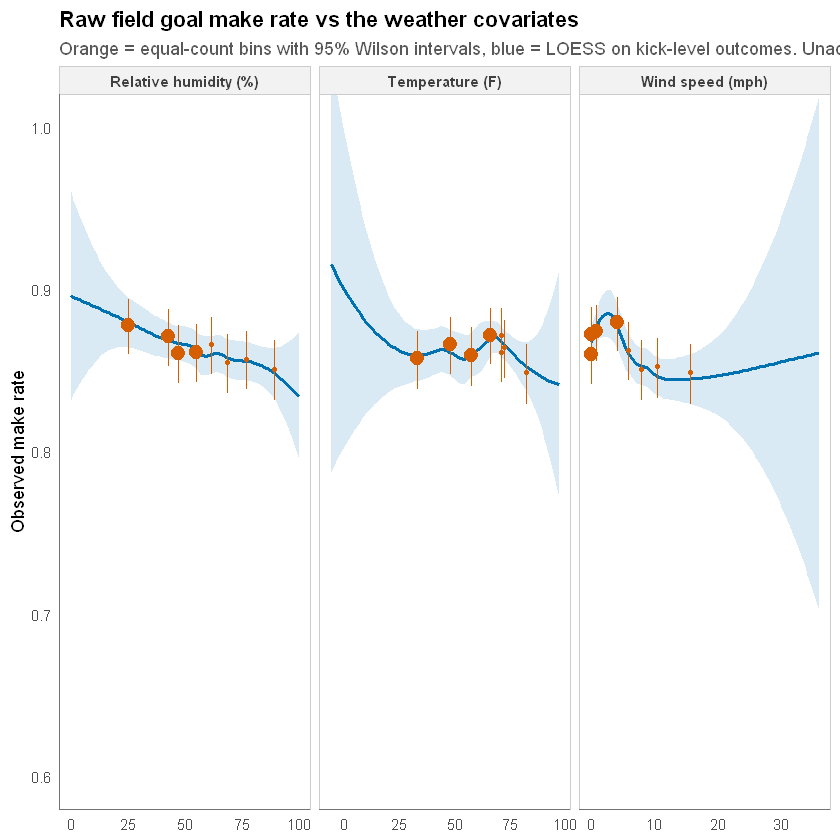

Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/weather_make_rate_40_54.png



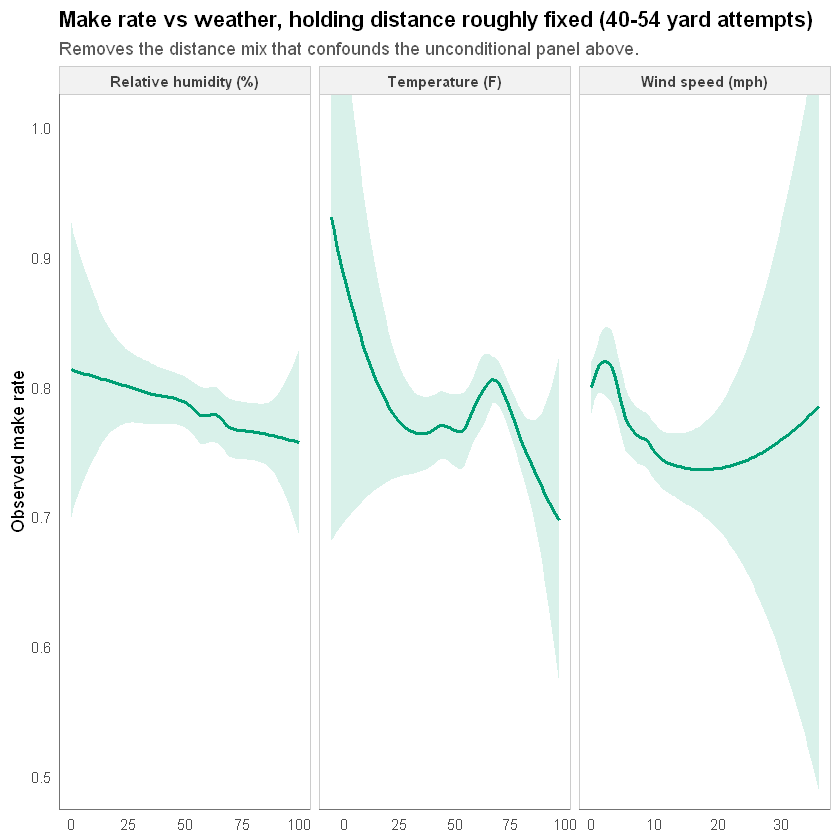

In [10]:
# --- Raw make rate vs the weather variables (reviewer: "What is the
# relationship between the weather variables and probability of success?") ---
# Shown on the RAW (unstandardized) scales, from the data rather than from the
# model, so the assumed non-linearity is demonstrated instead of asserted.
# Points are equal-count bins with 95% Wilson intervals; the curve is a LOESS
# fit on the underlying kick-level 0/1 outcomes.

# 01_data_prep corrects physically implausible wind readings (> 40 mph) at the
# source, so no display-time trimming is needed here.
weather_panel_df <- preds_is %>%
  dplyr::filter(!is.na(kick_made)) %>%
  dplyr::select(kick_made, kick_distance, wind, temp, humidity) %>%
  tidyr::pivot_longer(c(wind, temp, humidity),
                      names_to = 'var', values_to = 'value') %>%
  dplyr::filter(!is.na(value)) %>%
  dplyr::mutate(var = dplyr::recode(var,
    wind = 'Wind speed (mph)', temp = 'Temperature (F)', humidity = 'Relative humidity (%)'))

weather_bins <- weather_panel_df %>%
  dplyr::group_by(var) %>%
  # ntile() rather than cut_number(): temperature and humidity carry heavy ties
  # from the indoor/imputed values, and quantile-based cutting cannot form
  # distinct breaks when a single value spans more than one bin boundary.
  dplyr::mutate(bin = dplyr::ntile(value, 8)) %>%
  dplyr::group_by(var, bin) %>%
  dplyr::summarise(x = mean(value), obs = mean(kick_made),
                   k = sum(kick_made), n = dplyr::n(), .groups = 'drop') %>%
  dplyr::bind_cols(wilson_ci(.$k, .$n))

p_weather <- ggplot(weather_panel_df, aes(value, kick_made)) +
  geom_smooth(method = 'loess', formula = y ~ x, se = TRUE,
              colour = '#0072B2', fill = '#0072B2', alpha = 0.15, linewidth = 0.9) +
  geom_errorbar(data = weather_bins, aes(x = x, y = obs, ymin = lo, ymax = hi),
                width = 0, colour = '#D55E00', linewidth = 0.5, inherit.aes = FALSE) +
  geom_point(data = weather_bins, aes(x = x, y = obs, size = n),
             colour = '#D55E00', inherit.aes = FALSE) +
  scale_size_continuous(range = c(1.2, 3.6), guide = 'none') +
  facet_wrap(~ var, scales = 'free_x', nrow = 1) +
  coord_cartesian(ylim = c(0.6, 1)) +
  labs(title = 'Raw field goal make rate vs the weather covariates',
       subtitle = 'Orange = equal-count bins with 95% Wilson intervals, blue = LOESS on kick-level outcomes. Unadjusted for distance.',
       x = NULL, y = 'Observed make rate') +
  theme_paper()

print(p_weather)
save_fig(p_weather, 'weather_make_rate_raw.png', w = 11, h = 4.2)

# Distance is the dominant confounder here -- longer kicks are also windier on
# average -- so the same relationships are shown again within a fixed distance
# band, where the weather signal is not contaminated by distance mix.
p_weather_band <- weather_panel_df %>%
  dplyr::filter(kick_distance >= 40, kick_distance < 55) %>%
  ggplot(aes(value, kick_made)) +
  geom_smooth(method = 'loess', formula = y ~ x, se = TRUE,
              colour = '#009E73', fill = '#009E73', alpha = 0.15, linewidth = 0.9) +
  facet_wrap(~ var, scales = 'free_x', nrow = 1) +
  coord_cartesian(ylim = c(0.5, 1)) +
  labs(title = 'Make rate vs weather, holding distance roughly fixed (40-54 yard attempts)',
       subtitle = 'Removes the distance mix that confounds the unconditional panel above.',
       x = NULL, y = 'Observed make rate') +
  theme_paper()

print(p_weather_band)
save_fig(p_weather_band, 'weather_make_rate_40_54.png', w = 11, h = 4.2)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/brier_comparison_is_oos.png



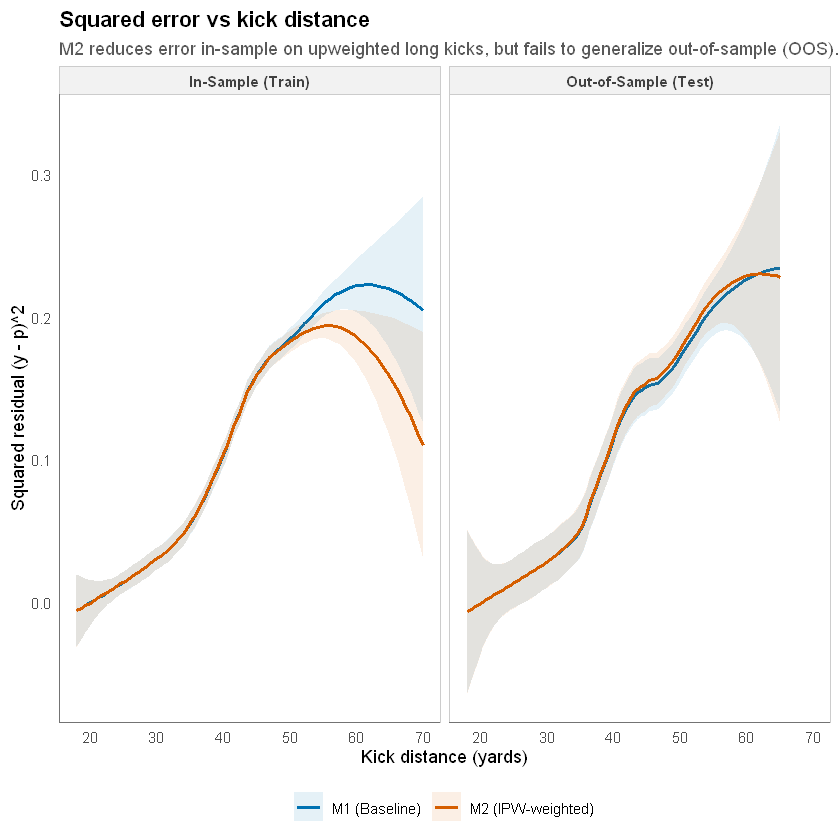

In [11]:
# --- Squared error vs kick distance ---
is_brier_data <- preds_is %>%
  filter(!is.na(kick_made)) %>%
  select(kick_distance, kick_made, p_m1_full, p_m2_full) %>%
  mutate(
    res_sq_M1 = (kick_made - p_m1_full)^2,
    res_sq_M2 = (kick_made - p_m2_full)^2
  ) %>%
  pivot_longer(cols = c(res_sq_M1, res_sq_M2), names_to = 'Model', values_to = 'Sq_Residual') %>%
  mutate(
    Model = recode(Model, res_sq_M1 = 'M1 (Baseline)', res_sq_M2 = 'M2 (IPW-weighted)'),
    split = 'In-Sample (Train)'
  )

oos_brier_data <- preds_test %>%
  filter(!is.na(kick_made)) %>%
  select(kick_distance, kick_made, p_m1, p_m2) %>%
  mutate(
    res_sq_M1 = (kick_made - p_m1)^2,
    res_sq_M2 = (kick_made - p_m2)^2
  ) %>%
  pivot_longer(cols = c(res_sq_M1, res_sq_M2), names_to = 'Model', values_to = 'Sq_Residual') %>%
  mutate(
    Model = recode(Model, res_sq_M1 = 'M1 (Baseline)', res_sq_M2 = 'M2 (IPW-weighted)'),
    split = 'Out-of-Sample (Test)'
  )

brier_dist_data <- bind_rows(is_brier_data, oos_brier_data)

p_brier_dist <- ggplot(brier_dist_data, aes(x = kick_distance, y = Sq_Residual, color = Model, fill = Model)) +
  geom_smooth(method = 'loess', formula = y ~ x, span = 0.5, se = TRUE, alpha = 0.1, linewidth = 1.0) +
  facet_wrap(~ split, ncol = 2) +
  scale_color_manual(values = c('M1 (Baseline)' = '#0072B2', 'M2 (IPW-weighted)' = '#D55E00')) +
  scale_fill_manual(values = c('M1 (Baseline)' = '#0072B2', 'M2 (IPW-weighted)' = '#D55E00')) +
  labs(
    title = 'Squared error vs kick distance',
    subtitle = 'M2 reduces error in-sample on upweighted long kicks, but fails to generalize out-of-sample (OOS).',
    x = 'Kick distance (yards)',
    y = 'Squared residual (y - p)^2',
    color = NULL, fill = NULL
  ) +
  theme_paper()
print(p_brier_dist)
save_fig(p_brier_dist, 'brier_comparison_is_oos.png', w = 11, h = 5.5)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/brier_distance_test.png



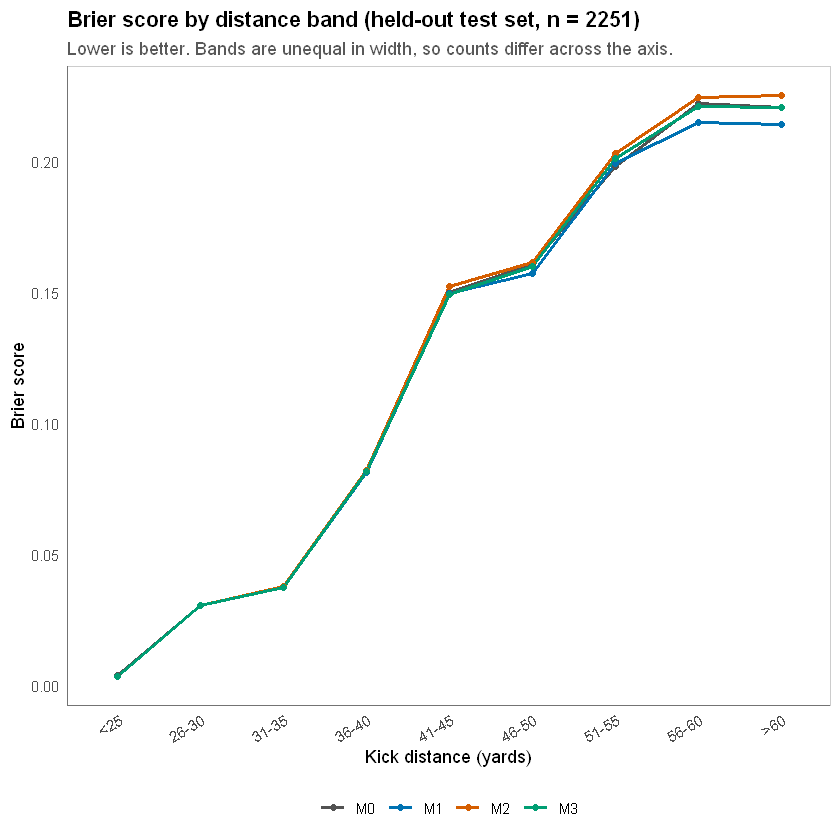

In [12]:
# --- Brier Score by Distance Band (Test Set) ---
resid_df_test <- preds_test %>%
  filter(!is.na(kick_made)) %>%
  mutate(dist_bin = cut(kick_distance,
    breaks = c(-Inf, 25, 30, 35, 40, 45, 50, 55, 60, Inf),
    labels = c('<25','26-30','31-35','36-40','41-45','46-50','51-55','56-60','>60'),
    include.lowest = TRUE)) %>%
  pivot_longer(c(p_m0, p_m1, p_m2, p_m3),
                      names_to = 'model', values_to = 'p') %>%
  mutate(model = toupper(stringr::str_remove(model, 'p_'))) %>%
  group_by(model, dist_bin) %>%
  summarise(brier_bin = brier(kick_made, p), n = n(), .groups = 'drop')

p_resid_test <- ggplot(resid_df_test,
    aes(dist_bin, brier_bin, group = model, colour = model)) +
  geom_line(linewidth = 0.9) +
  geom_point() +
  scale_colour_manual(values = model_cols) +
  labs(title = paste0('Brier score by distance band (held-out test set, n = ', nrow(preds_test), ')'),
    subtitle = 'Lower is better. Bands are unequal in width, so counts differ across the axis.',
    x = 'Kick distance (yards)', y = 'Brier score', colour = NULL) +
  theme_paper() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))
print(p_resid_test)
save_fig(p_resid_test, 'brier_distance_test.png')


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/bias_curve_comparison_is_oos.png



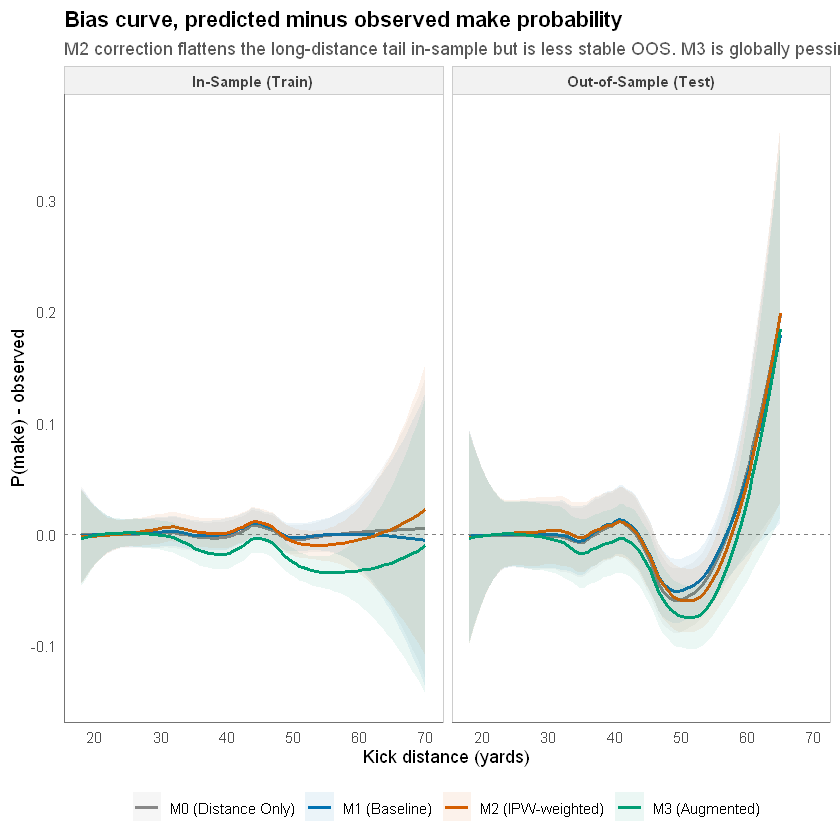

In [13]:
# --- Bias Curve: Predicted minus Observed (All 4 Models) ---
is_bias_data <- preds_is %>%
  filter(!is.na(kick_made)) %>%
  select(kick_distance, kick_made, p_m0_full, p_m1_full, p_m2_full, p_m3_full) %>%
  mutate(
    bias_M0 = p_m0_full - kick_made,
    bias_M1 = p_m1_full - kick_made,
    bias_M2 = p_m2_full - kick_made,
    bias_M3 = p_m3_full - kick_made
  ) %>%
  pivot_longer(cols = c(bias_M0, bias_M1, bias_M2, bias_M3),
               names_to = 'Model', values_to = 'Residual') %>%
  mutate(
    Model = recode(Model,
      bias_M0 = 'M0 (Distance Only)',
      bias_M1 = 'M1 (Baseline)',
      bias_M2 = 'M2 (IPW-weighted)',
      bias_M3 = 'M3 (Augmented)'
    ),
    split = 'In-Sample (Train)'
  )

oos_bias_data <- preds_test %>%
  filter(!is.na(kick_made)) %>%
  select(kick_distance, kick_made, p_m0, p_m1, p_m2, p_m3) %>%
  mutate(
    bias_M0 = p_m0 - kick_made,
    bias_M1 = p_m1 - kick_made,
    bias_M2 = p_m2 - kick_made,
    bias_M3 = p_m3 - kick_made
  ) %>%
  pivot_longer(cols = c(bias_M0, bias_M1, bias_M2, bias_M3),
               names_to = 'Model', values_to = 'Residual') %>%
  mutate(
    Model = recode(Model,
      bias_M0 = 'M0 (Distance Only)',
      bias_M1 = 'M1 (Baseline)',
      bias_M2 = 'M2 (IPW-weighted)',
      bias_M3 = 'M3 (Augmented)'
    ),
    split = 'Out-of-Sample (Test)'
  )

bias_dist_data <- bind_rows(is_bias_data, oos_bias_data) %>%
  mutate(Model = factor(Model, levels = c(
    'M0 (Distance Only)', 'M1 (Baseline)',
    'M2 (IPW-weighted)', 'M3 (Augmented)'
  )))

p_bias_dist <- ggplot(bias_dist_data,
    aes(x = kick_distance, y = Residual, color = Model, fill = Model)) +
  geom_hline(yintercept = 0, lty = 2, colour = 'grey50') +
  geom_smooth(method = 'loess', formula = y ~ x, span = 0.5,
              se = TRUE, alpha = 0.08, linewidth = 0.9) +
  facet_wrap(~ split, ncol = 2) +
  scale_color_manual(values = c(
    'M0 (Distance Only)' = '#888888',
    'M1 (Baseline)'      = '#0072B2',
    'M2 (IPW-weighted)'  = '#D55E00',
    'M3 (Augmented)'     = '#009E73'
  )) +
  scale_fill_manual(values = c(
    'M0 (Distance Only)' = '#888888',
    'M1 (Baseline)'      = '#0072B2',
    'M2 (IPW-weighted)'  = '#D55E00',
    'M3 (Augmented)'     = '#009E73'
  )) +
  labs(
    title = 'Bias curve, predicted minus observed make probability',
    subtitle = 'M2 correction flattens the long-distance tail in-sample but is less stable OOS. M3 is globally pessimistic.',
    x = 'Kick distance (yards)',
    y = 'P(make) - observed',
    color = NULL, fill = NULL
  ) +
  theme_paper()
print(p_bias_dist)
save_fig(p_bias_dist, 'bias_curve_comparison_is_oos.png', w = 12, h = 5.5)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/separation_density.png



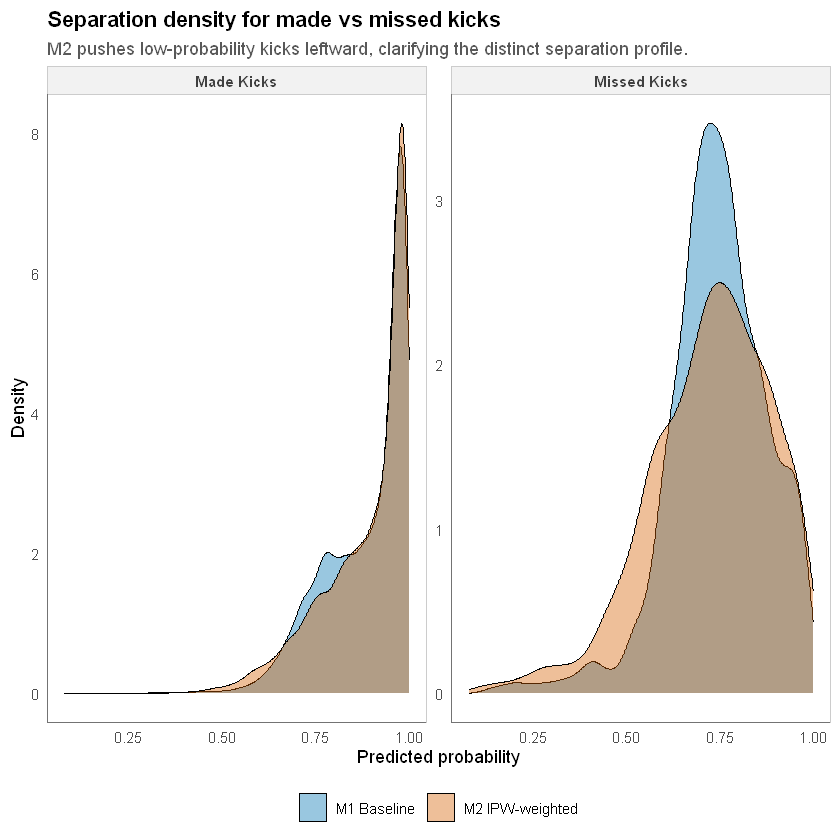

In [14]:
# --- Separation density for made vs missed kicks ---
dist_plot_data <- preds_is %>%
  filter(!is.na(kick_made)) %>%
  select(kick_made, p_m1_full, p_m2_full) %>%
  pivot_longer(cols = c(p_m1_full, p_m2_full), names_to = 'Model', values_to = 'Probability') %>%
  mutate(
    Model = recode(Model, p_m1_full = 'M1 Baseline', p_m2_full = 'M2 IPW-weighted'),
    Outcome = ifelse(kick_made == 1, 'Made Kicks', 'Missed Kicks')
  )

p_dens_sep <- ggplot(dist_plot_data, aes(x = Probability, fill = Model)) +
  geom_density(alpha = 0.4, linewidth = 0.3) +
  facet_wrap(~ Outcome, scales = 'free_y') +
  scale_fill_manual(values = c('M1 Baseline' = '#0072B2', 'M2 IPW-weighted' = '#D55E00')) +
  labs(
    title = 'Separation density for made vs missed kicks',
    subtitle = 'M2 pushes low-probability kicks leftward, clarifying the distinct separation profile.',
    x = 'Predicted probability',
    y = 'Density',
    fill = NULL
  ) +
  theme_paper()
print(p_dens_sep)
save_fig(p_dens_sep, 'separation_density.png', w = 10, h = 5)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/tail_density_50plus.png



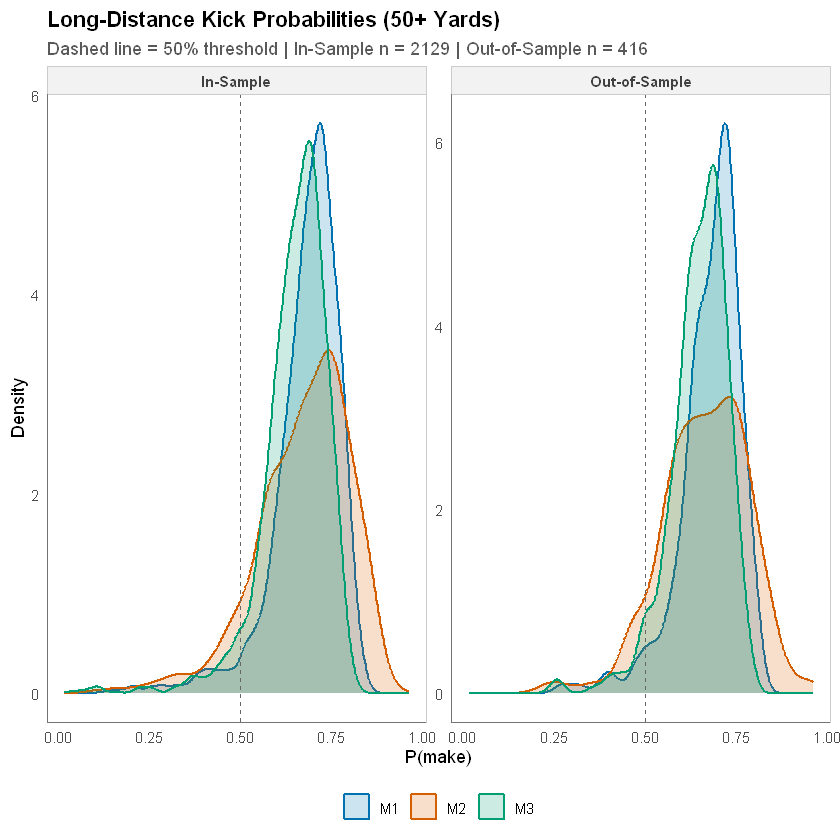

In [15]:
# --- Long-Distance Kick Probabilities (50+ Yards) ---
tail_is <- preds_is %>%
  filter(!is.na(kick_made), kick_distance >= 50) %>%
  select(kick_made, kick_distance, p_m1 = p_m1_full, p_m2 = p_m2_full, p_m3 = p_m3_full) %>%
  mutate(split = "In-Sample")
  
tail_test <- preds_test %>%
  filter(!is.na(kick_made), kick_distance >= 50) %>%
  select(kick_made, kick_distance, p_m1, p_m2, p_m3) %>%
  mutate(split = "Out-of-Sample")
  
tail_combined <- dplyr::bind_rows(tail_is, tail_test) %>%
  pivot_longer(c(p_m1, p_m2, p_m3),
                      names_to = 'model', values_to = 'prob') %>%
  mutate(model = toupper(stringr::str_remove(model, 'p_')),
         split = factor(split, levels = c("In-Sample", "Out-of-Sample")))

n_tail_is <- nrow(tail_is)
n_tail_test <- nrow(tail_test)

p_tail <- ggplot(tail_combined,
    ggplot2::aes(prob, colour = model, fill = model)) +
  ggplot2::geom_density(alpha = 0.2, linewidth = 0.8) +
  ggplot2::geom_vline(xintercept = 0.5, lty = 2, colour = 'grey40') +
  ggplot2::facet_wrap(~ split, scales = "free_y") +
  ggplot2::scale_colour_manual(values = model_cols_3) +
  ggplot2::scale_fill_manual(values = model_cols_3) +
  ggplot2::labs(
    title   = paste0('Long-Distance Kick Probabilities (50+ Yards)'),
    subtitle = paste0('Dashed line = 50% threshold | In-Sample n = ', n_tail_is, ' | Out-of-Sample n = ', n_tail_test),
    x = 'P(make)', y = 'Density', colour = NULL, fill = NULL) +
  theme_paper()
print(p_tail)
save_fig(p_tail, 'tail_density_50plus.png', w = 10, h = 5)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/M1_M2_M3_Accuracy_Bias_Annotated.png



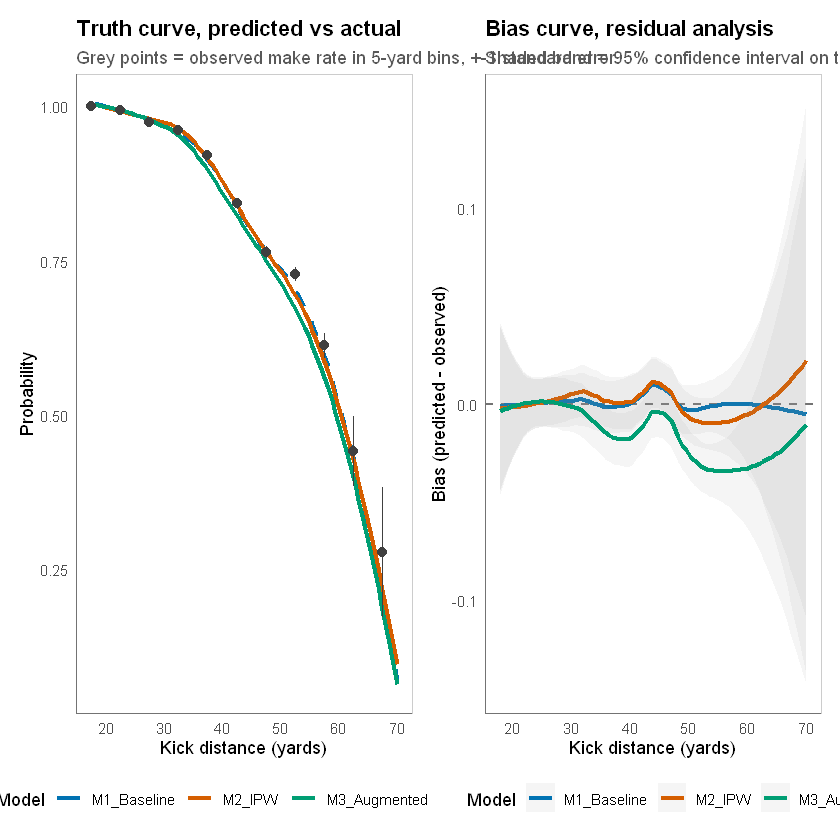

In [16]:
# --- M1/M2/M3 Truth Curve + Bias Annotated ---
comparison_df_m1_m2_m3 <- fg_full_pooled %>%
  dplyr::select(kick_made, kick_distance, M1_Baseline = pred_m1_full, M2_IPW = pred_m2_full, M3_Augmented = pred_m3_full)

truth_binned_m1_m2_m3 <- comparison_df_m1_m2_m3 %>%
  mutate(bin_start = floor(kick_distance / 5) * 5) %>%
  group_by(bin_start) %>%
  summarise(n = n(), obs_prob = mean(kick_made), se = sqrt((obs_prob * (1 - obs_prob)) / n), .groups = "drop") %>%
  filter(n > 10)

plot_curve_data_m1_m2_m3 <- comparison_df_m1_m2_m3 %>%
  pivot_longer(cols = c(M1_Baseline, M2_IPW, M3_Augmented), names_to = "Model", values_to = "Prob")

bias_data_m1_m2_m3 <- plot_curve_data_m1_m2_m3 %>%
  mutate(Residual = Prob - kick_made)

p_truth_annotated <- ggplot() +
  geom_smooth(data = plot_curve_data_m1_m2_m3, 
              aes(x = kick_distance, y = Prob, color = Model, linetype = Model), 
              method = "loess", formula = y ~ x, span = 0.5, linewidth = 1.2, se = FALSE) +
  geom_point(data = truth_binned_m1_m2_m3, aes(x = bin_start + 2.5, y = obs_prob), size = 2.4, colour = "grey25") +
  geom_errorbar(data = truth_binned_m1_m2_m3, aes(x = bin_start + 2.5, ymin = obs_prob - se, ymax = obs_prob + se), width = 0, colour = "grey25", linewidth = 0.5) +
  scale_color_manual(values = cols_okabe_3) +
  scale_linetype_manual(values = c("dashed", "solid", "solid"), guide = "none") +
  labs(title = "Truth curve, predicted vs actual",
       subtitle = "Grey points = observed make rate in 5-yard bins, +-1 standard error.",
       x = "Kick distance (yards)", y = "Probability") +
  theme_paper() + theme(legend.position = "bottom")

p_bias_annotated <- ggplot(bias_data_m1_m2_m3, aes(x = kick_distance, y = Residual, color = Model)) +
  geom_hline(yintercept = 0, colour = "grey45", linewidth = 0.6, linetype = 2) +
  geom_smooth(method = "loess", formula = y ~ x, span = 0.5, se = TRUE, alpha = 0.1, linewidth = 1.2) +
  scale_color_manual(values = cols_okabe_3) +
  labs(title = "Bias curve, residual analysis",
       subtitle = "Shaded band = 95% confidence interval on the LOESS fit.",
       x = "Kick distance (yards)", y = "Bias (predicted - observed)") +
  theme_paper() + theme(legend.position = "bottom")

fig1_annotated <- p_truth_annotated + p_bias_annotated + plot_layout(guides = "collect") & theme(legend.position = 'bottom')
print(fig1_annotated)
save_fig(fig1_annotated, "M1_M2_M3_Accuracy_Bias_Annotated.png", w = 12, h = 8)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/M1_M2_M3_Distributions_Outlined.png



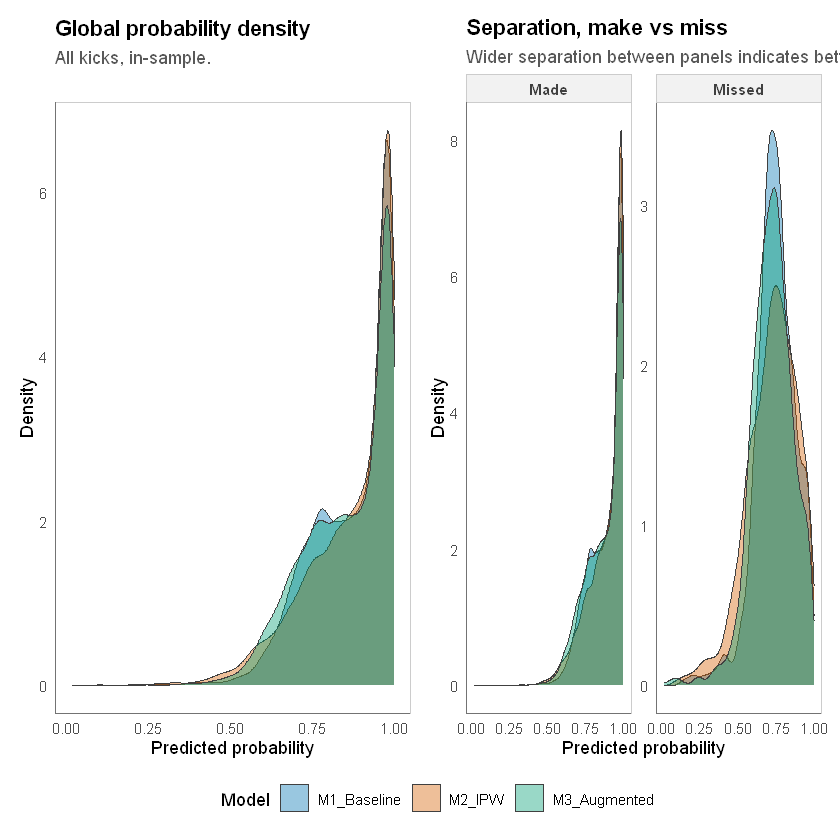

In [17]:
# --- M1/M2/M3 Probability Distributions ---
dist_plot_data_m1_m2_m3 <- comparison_df_m1_m2_m3 %>%
  pivot_longer(cols = c(M1_Baseline, M2_IPW, M3_Augmented), names_to = "Model", values_to = "Probability") %>%
  mutate(Outcome = ifelse(kick_made == 1, "Made", "Missed"))

p_dens_global <- ggplot(dist_plot_data_m1_m2_m3, aes(x = Probability, fill = Model)) +
  geom_density(alpha = 0.4, colour = "grey25", linewidth = 0.3) + 
  scale_fill_manual(values = cols_okabe_3) +
  labs(title = "Global probability density",
       subtitle = "All kicks, in-sample.",
       x = "Predicted probability", y = "Density") +
  theme_paper() + theme(legend.position = "bottom")

p_dens_sep_outline <- ggplot(dist_plot_data_m1_m2_m3, aes(x = Probability, fill = Model)) +
  geom_density(alpha = 0.4, colour = "grey25", linewidth = 0.3) +
  facet_wrap(~Outcome, scales = "free_y") +
  scale_fill_manual(values = cols_okabe_3) +
  labs(title = "Separation, make vs miss",
       subtitle = "Wider separation between panels indicates better discrimination.",
       x = "Predicted probability", y = "Density") +
  theme_paper() + theme(legend.position = "bottom")

fig2_outlined <- p_dens_global + p_dens_sep_outline + plot_layout(guides = "collect") & theme(legend.position = 'bottom')
print(fig2_outlined)
save_fig(fig2_outlined, "M1_M2_M3_Distributions_Outlined.png", w = 12, h = 8)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/M1_M2_M3_Metrics_Split_50plus.png



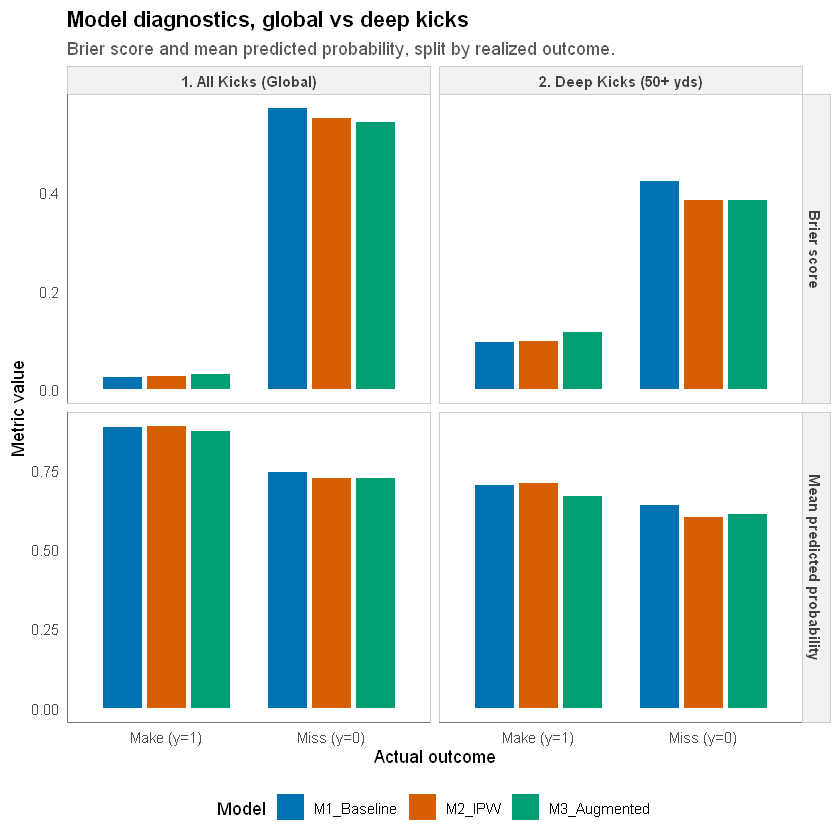

In [18]:
# --- Model diagnostics, global vs deep kicks ---
metrics_global <- calc_metrics_subset(comparison_df_m1_m2_m3, "1. All Kicks (Global)")
metrics_deep <- calc_metrics_subset(comparison_df_m1_m2_m3 %>% filter(kick_distance >= 50), "2. Deep Kicks (50+ yds)")

plot_data_split <- bind_rows(metrics_global, metrics_deep) %>%
  pivot_longer(cols = c(Brier, Mean_Prob), names_to = "Metric", values_to = "Value") %>%
  dplyr::mutate(Metric = dplyr::recode(Metric,
    Brier = "Brier score", Mean_Prob = "Mean predicted probability"))

p_split_metrics <- ggplot(plot_data_split, aes(x = Outcome_Label, y = Value, fill = Model)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  facet_grid(Metric ~ Subset, scales = "free_y") +
  scale_fill_manual(values = cols_okabe_3) +
  labs(
    title = "Model diagnostics, global vs deep kicks",
    subtitle = "Brier score and mean predicted probability, split by realized outcome.",
    x = "Actual outcome",
    y = "Metric value"
  ) +
  theme_paper() +
  theme(legend.position = "bottom", strip.text = element_text(face = "bold"))
print(p_split_metrics)
save_fig(p_split_metrics, "M1_M2_M3_Metrics_Split_50plus.png", w = 12, h = 8)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/m3_weight_sensitivity.png



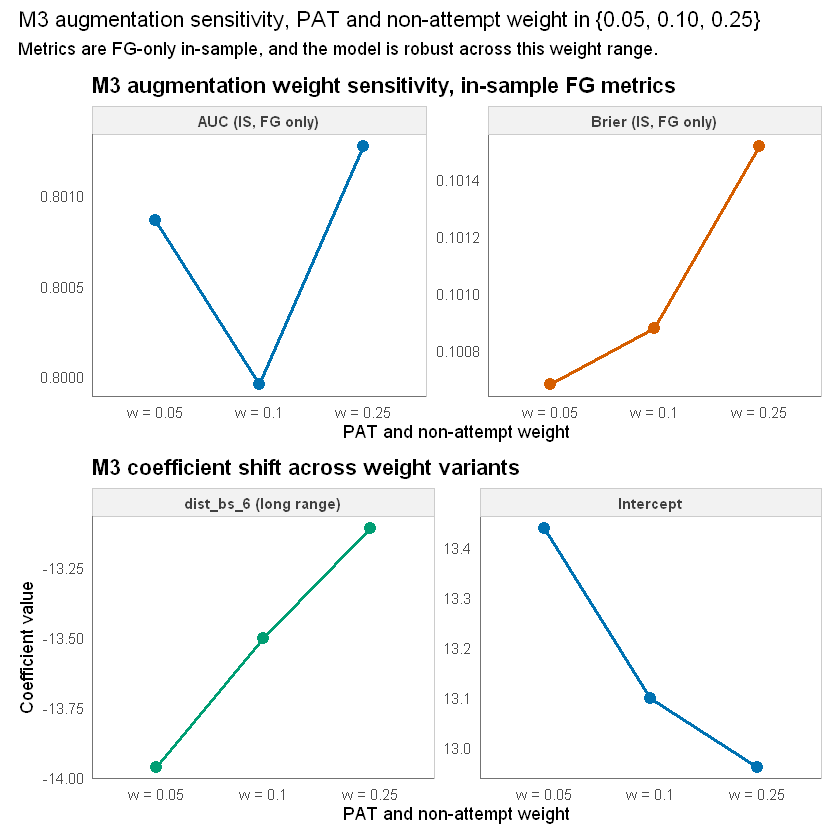

In [19]:
# --- M3 Augmentation Weight Sensitivity ---
grid_df <- readr::read_csv(file.path(reports_dir, 'xfg_success', 'm3_weight_grid.csv'), show_col_types = FALSE) %>%
  mutate(weight_label = paste0('w = ', pat_weight))

grid_metrics <- grid_df %>%
  pivot_longer(c(auc_is_fg, brier_is_fg), names_to = 'metric', values_to = 'value') %>%
  mutate(metric = dplyr::recode(metric, 'auc_is_fg' = 'AUC (IS, FG only)', 'brier_is_fg' = 'Brier (IS, FG only)'))

p_grid_metrics <- ggplot(grid_metrics, aes(weight_label, value, group = metric, colour = metric)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 3) +
  facet_wrap(~ metric, scales = 'free_y', ncol = 2) +
  scale_colour_manual(values = c('AUC (IS, FG only)' = '#0072B2', 'Brier (IS, FG only)' = '#D55E00'), guide = 'none') +
  labs(title = 'M3 augmentation weight sensitivity, in-sample FG metrics', x = 'PAT and non-attempt weight', y = NULL) +
  theme_paper()

grid_coefs <- grid_df %>%
  pivot_longer(c(coef_intercept, coef_dist_bs_6), names_to = 'coef', values_to = 'value') %>%
  mutate(coef = dplyr::recode(coef, 'coef_intercept' = 'Intercept', 'coef_dist_bs_6' = 'dist_bs_6 (long range)'))

p_grid_coefs <- ggplot(grid_coefs, aes(weight_label, value, group = coef, colour = coef)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 3) +
  facet_wrap(~ coef, scales = 'free_y', ncol = 2) +
  scale_colour_manual(values = c('Intercept' = '#0072B2', 'dist_bs_6 (long range)' = '#009E73'), guide = 'none') +
  labs(title = 'M3 coefficient shift across weight variants', x = 'PAT and non-attempt weight', y = 'Coefficient value') +
  theme_paper()

p_m3_grid <- p_grid_metrics / p_grid_coefs +
  plot_annotation(
    title    = 'M3 augmentation sensitivity, PAT and non-attempt weight in {0.05, 0.10, 0.25}',
    subtitle = 'Metrics are FG-only in-sample, and the model is robust across this weight range.'
  )
print(p_m3_grid)
save_fig(p_m3_grid, 'm3_weight_sensitivity.png', w = 9, h = 7)


## Section 6: FGOE & Player Evaluations


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/fgoe_leaderboard.png



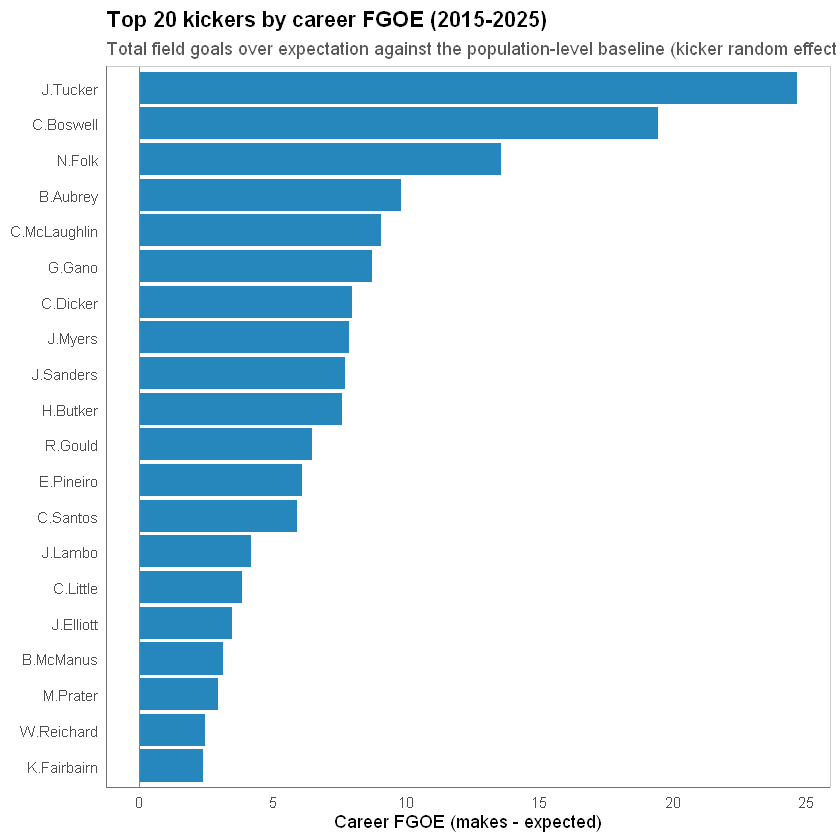

In [20]:
# --- FGOE Total Leaderboard ---
leaderboard <- preds_is %>%
  filter(!is.na(kick_made), !is.na(p_m2_pop)) %>%
  group_by(kicker_player_id, kicker_player_name) %>%
  summarise(
    attempts   = n(),
    makes      = sum(kick_made),
    xfg        = sum(p_m2_pop),
    fgoe_total = sum(fgoe_pop),
    fgoe_per   = fgoe_total / attempts,
    .groups    = 'drop'
  ) %>%
  filter(attempts >= MIN_FGOE_ATT) %>%
  arrange(desc(fgoe_total))

top20 <- leaderboard %>% slice_head(n = 20)

p_leader <- ggplot(top20, aes(x = fgoe_total, y = reorder(kicker_player_name, fgoe_total))) +
  geom_col(fill = '#0072B2', alpha = 0.85) +
  geom_vline(xintercept = 0, colour = 'grey50') +
  labs(
    title    = 'Top 20 kickers by career FGOE (2015-2025)',
    subtitle = 'Total field goals over expectation against the population-level baseline (kicker random effect zeroed).',
    x = 'Career FGOE (makes - expected)', y = NULL) +
  theme_paper()
print(p_leader)
save_fig(p_leader, 'fgoe_leaderboard.png', h = 6.5)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/fgoe_rate_leaderboard.png



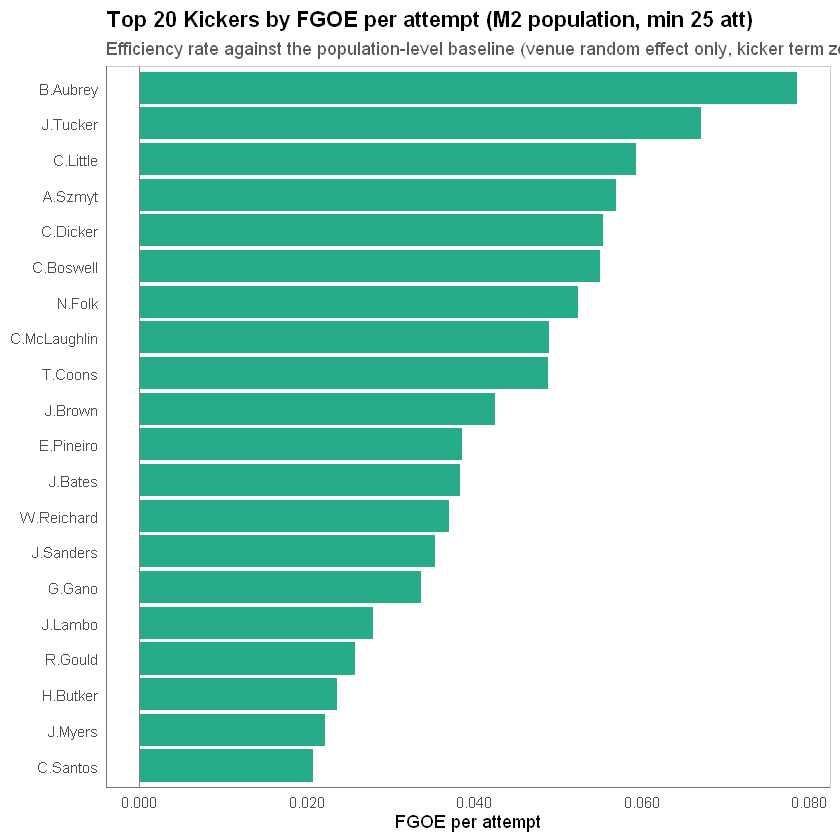

In [21]:
# --- FGOE per attempt Leaderboard ---
rate_leader <- leaderboard %>%
  arrange(desc(fgoe_per)) %>%
  slice_head(n = 20)

p_rate_leader <- ggplot(rate_leader, aes(x = fgoe_per, y = reorder(kicker_player_name, fgoe_per))) +
  geom_col(fill = '#009E73', alpha = 0.85) +
  geom_vline(xintercept = 0, colour = 'grey50') +
  scale_x_continuous(labels = scales::number_format(accuracy = 0.001)) +
  labs(
    title = paste0('Top 20 Kickers by FGOE per attempt (M2 population, min ', MIN_FGOE_ATT, ' att)'),
    subtitle = 'Efficiency rate against the population-level baseline (venue random effect only, kicker term zeroed).',
    x = 'FGOE per attempt', y = NULL
  ) +
  theme_paper()
print(p_rate_leader)
save_fig(p_rate_leader, 'fgoe_rate_leaderboard.png', h = 6.5)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/skill_vs_workload_scatter.png



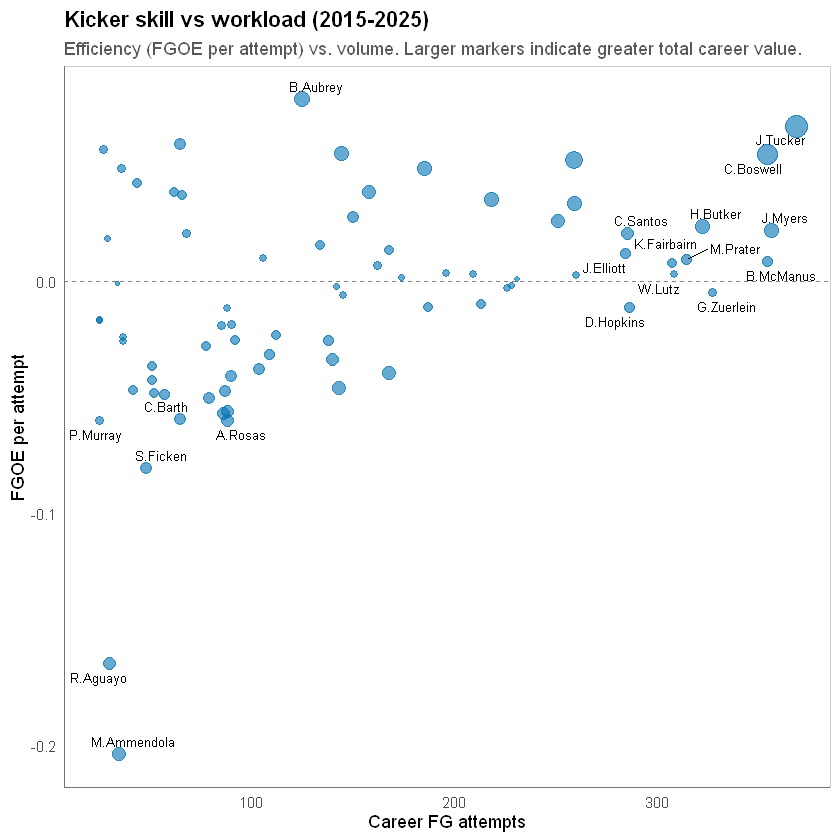

In [22]:
# --- Kicker Skill vs. Workload ---
p_skill <- ggplot(leaderboard, aes(attempts, fgoe_per, label = kicker_player_name)) +
  geom_point(aes(size = abs(fgoe_total)), alpha = 0.6, colour = '#0072B2') +
  geom_text_repel(
    data = leaderboard %>% filter(
      attempts > quantile(attempts, 0.85, na.rm = TRUE) |
      abs(fgoe_per) > quantile(abs(fgoe_per), 0.90, na.rm = TRUE)
    ),
    mapping = aes(attempts, fgoe_per, label = kicker_player_name),
    size = 2.8, max.overlaps = 20, inherit.aes = FALSE
  ) +
  geom_hline(yintercept = 0, lty = 2, colour = 'grey50') +
  scale_size_continuous(range = c(1, 6), guide = 'none') +
  labs(
    title    = 'Kicker skill vs workload (2015-2025)',
    subtitle = 'Efficiency (FGOE per attempt) vs. volume. Larger markers indicate greater total career value.',
    x = 'Career FG attempts',
    y = 'FGOE per attempt'
  ) +
  theme_paper()
print(p_skill)
save_fig(p_skill, 'skill_vs_workload_scatter.png')


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/kicker_workload_propensity.png



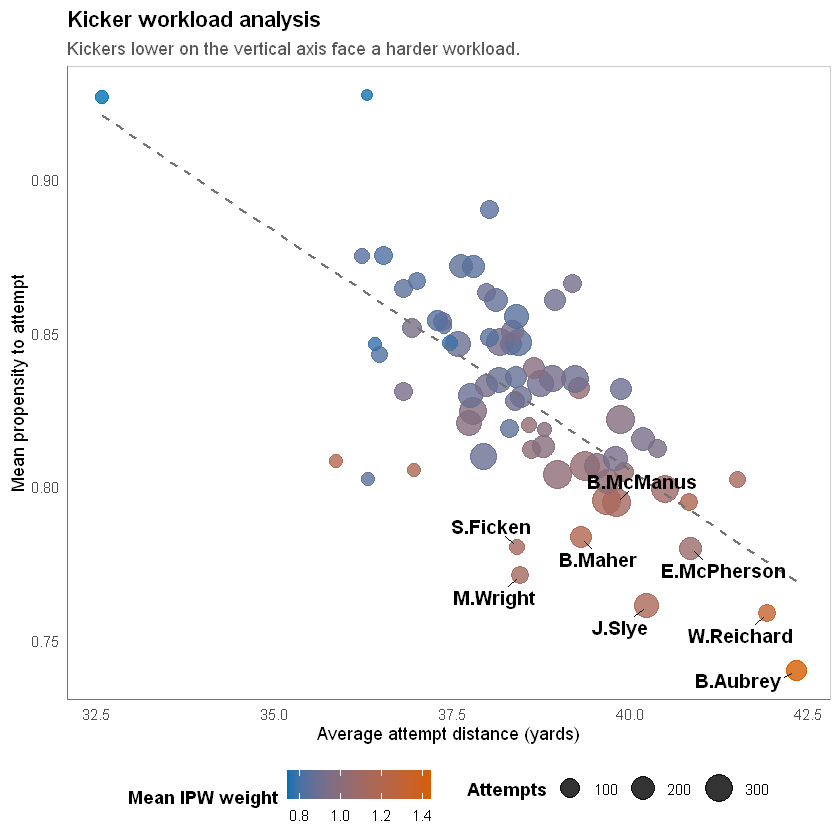

In [23]:
# --- Kicker workload analysis ---
kicker_propensity <- fg_full_pooled %>%
  group_by(kicker_player_name) %>%
  summarise(
    n_attempts = n(),
    mean_attempt_prob = mean(p_hat_multinom, na.rm = TRUE),
    avg_distance = mean(kick_distance, na.rm = TRUE),
    avg_weight = mean(as.numeric(weight_multinom_hajek), na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(n_attempts >= 30) %>%
  arrange(mean_attempt_prob)

p_prop <- ggplot(kicker_propensity, aes(x = avg_distance, y = mean_attempt_prob)) +
  geom_point(aes(size = n_attempts, color = avg_weight), alpha = 0.8) +
  geom_smooth(method = "lm", formula = y ~ x, colour = "grey45", linetype = "dashed", se = FALSE, linewidth = 0.6) +
  geom_text_repel(
    data = head(kicker_propensity, 8), 
    aes(label = kicker_player_name), 
    size = 4, 
    fontface = "bold", 
    box.padding = 0.5,
    point.padding = 0.3,
    min.segment.length = 0
  ) +
  scale_color_gradient(low = "#0072B2", high = "#D55E00", name = "Mean IPW weight") +
  scale_size_continuous(range = c(3, 8), name = "Attempts") +
  labs(
    title = "Kicker workload analysis",
    subtitle = "Kickers lower on the vertical axis face a harder workload.",
    x = "Average attempt distance (yards)",
    y = "Mean propensity to attempt"
  ) +
  theme_paper() +
  theme(
    legend.position = "bottom",
    legend.box = "horizontal",
    legend.title = element_text(face = "bold")
  )
print(p_prop)
save_fig(p_prop, 'kicker_workload_propensity.png', w = 12, h = 8)


## Section 7: Field Goal Kicking Trends


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/season_kicking_trends_detailed.png



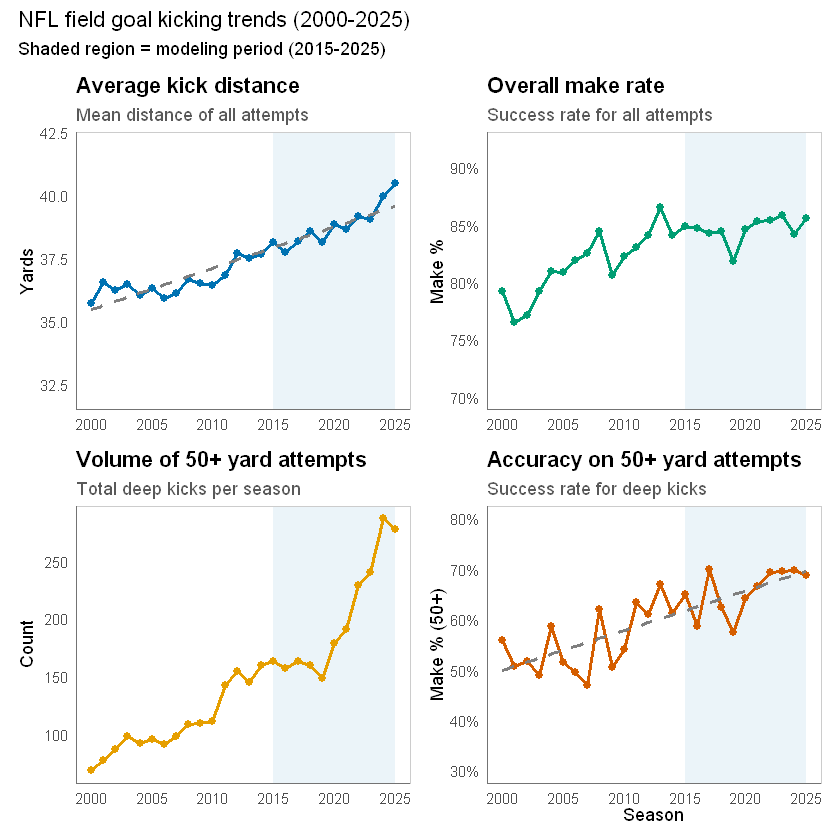

In [24]:
# --- Season Kicking Trends (2000-2025) ---
fg_trends_data <- fg_all %>%
  filter(play_type_original == 'field_goal', is_pat == 0) %>%
  filter(!is.na(kick_distance), !is.na(kick_made))

season_stats <- fg_trends_data %>%
  group_by(season) %>%
  summarise(
    n_kicks = n(),
    avg_distance = mean(kick_distance, na.rm = TRUE),
    make_pct = mean(kick_made, na.rm = TRUE),
    n_50_plus = sum(kick_distance >= 50, na.rm = TRUE),
    make_pct_50_plus = mean(kick_made[kick_distance >= 50], na.rm = TRUE),
    .groups = "drop"
  )

my_theme <- theme_paper() +
  theme(axis.title.x = element_blank())

# Shading for the modeling period (2015-2025)
shade <- annotate("rect", xmin = 2015, xmax = 2025, ymin = -Inf, ymax = Inf,
                  fill = "#0072B2", alpha = 0.08)

p1 <- ggplot(season_stats, aes(x = season, y = avg_distance)) +
  shade +
  geom_line(color = "#0072B2", linewidth = 1.0) +
  geom_point(color = "#0072B2", size = 1.8) +
  geom_smooth(method = "lm", formula = y ~ x, se = FALSE, linetype = "dashed", color = "grey50", alpha = 0.5) +
  scale_x_continuous(breaks = seq(2000, 2025, 5)) +
  coord_cartesian(ylim = c(32, 42)) +
  labs(title = "Average kick distance", subtitle = "Mean distance of all attempts", y = "Yards") +
  my_theme

p2 <- ggplot(season_stats, aes(x = season, y = make_pct)) +
  shade +
  geom_line(color = "#009E73", linewidth = 1.0) +
  geom_point(color = "#009E73", size = 1.8) +
  scale_x_continuous(breaks = seq(2000, 2025, 5)) +
  coord_cartesian(ylim = c(0.70, 0.92)) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  labs(title = "Overall make rate", subtitle = "Success rate for all attempts", y = "Make %") +
  my_theme

p3 <- ggplot(season_stats, aes(x = season, y = n_50_plus)) +
  shade +
  geom_line(color = "#E69F00", linewidth = 1.0) +
  geom_point(color = "#E69F00", size = 1.8) +
  scale_x_continuous(breaks = seq(2000, 2025, 5)) +
  labs(title = "Volume of 50+ yard attempts", subtitle = "Total deep kicks per season", y = "Count") +
  my_theme

p4 <- ggplot(season_stats, aes(x = season, y = make_pct_50_plus)) +
  shade +
  geom_line(color = "#D55E00", linewidth = 1.0) +
  geom_point(color = "#D55E00", size = 1.8) +
  geom_smooth(method = "lm", formula = y ~ x, se = FALSE, linetype = "dashed", color = "grey50", alpha = 0.5) +
  scale_x_continuous(breaks = seq(2000, 2025, 5)) +
  coord_cartesian(ylim = c(0.30, 0.80)) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  labs(title = "Accuracy on 50+ yard attempts", subtitle = "Success rate for deep kicks", y = "Make % (50+)") +
  my_theme + theme(axis.title.x = element_text()) + labs(x = 'Season')

combined_plot <- (p1 + p2) / (p3 + p4) +
  plot_annotation(
    title = 'NFL field goal kicking trends (2000-2025)',
    subtitle = 'Shaded region = modeling period (2015-2025)'
  )
print(combined_plot)
save_fig(combined_plot, "season_kicking_trends_detailed.png", w = 12, h = 10)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/kicking_decision_evolution.png



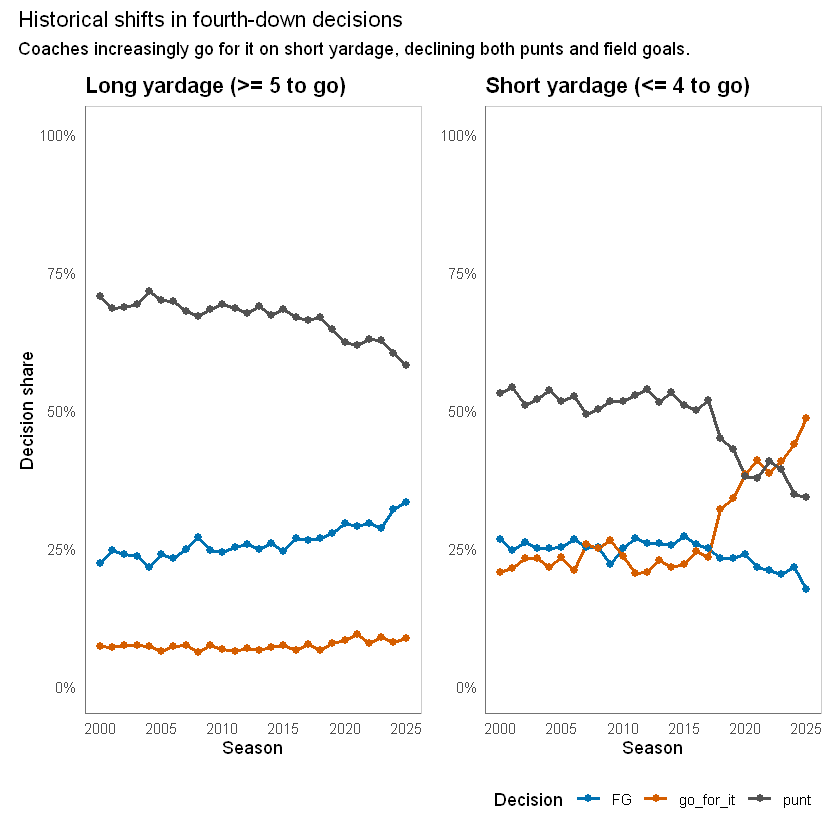

In [25]:
# --- 4th Down Decision Evolution by Yards-to-Go Regime ---
decision_evol_df <- decision %>%
  mutate(ydsgap = if_else(ydstogo >= 5, "Long (>= 5 yds)", "Short (<= 4 yds)")) %>%
  group_by(season, ydsgap, action) %>%
  summarise(count = n(), .groups = 'drop') %>%
  group_by(season, ydsgap) %>%
  mutate(pct = count / sum(count)) %>%
  ungroup()

p_evol_long <- decision_evol_df %>%
  filter(ydsgap == "Long (>= 5 yds)") %>%
  ggplot(aes(season, pct, colour = action, group = action)) +
  geom_line(linewidth = 1.0) +
  geom_point(size = 1.8) +
  scale_colour_manual(values = c('FG' = '#0072B2', 'punt' = '#525252', 'go_for_it' = '#D55E00')) +
  scale_y_continuous(labels = percent_format(accuracy = 1), limits = c(0, 1)) +
  scale_x_continuous(breaks = seq(2000, 2025, 5)) +
  labs(title = 'Long yardage (>= 5 to go)', x = 'Season', y = 'Decision share', colour = 'Decision') +
  theme_paper() + theme(legend.position = 'none')

p_evol_short <- decision_evol_df %>%
  filter(ydsgap == "Short (<= 4 yds)") %>%
  ggplot(aes(season, pct, colour = action, group = action)) +
  geom_line(linewidth = 1.0) +
  geom_point(size = 1.8) +
  scale_colour_manual(values = c('FG' = '#0072B2', 'punt' = '#525252', 'go_for_it' = '#D55E00')) +
  scale_y_continuous(labels = percent_format(accuracy = 1), limits = c(0, 1)) +
  scale_x_continuous(breaks = seq(2000, 2025, 5)) +
  labs(title = 'Short yardage (<= 4 to go)', x = 'Season', y = NULL, colour = 'Decision') +
  theme_paper()

p_decisions_comb <- p_evol_long + p_evol_short +
  plot_annotation(
    title = 'Historical shifts in fourth-down decisions',
    subtitle = 'Coaches increasingly go for it on short yardage, declining both punts and field goals.'
  )
print(p_decisions_comb)
save_fig(p_decisions_comb, 'kicking_decision_evolution.png', w = 11, h = 5)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/decision_by_field_position.png



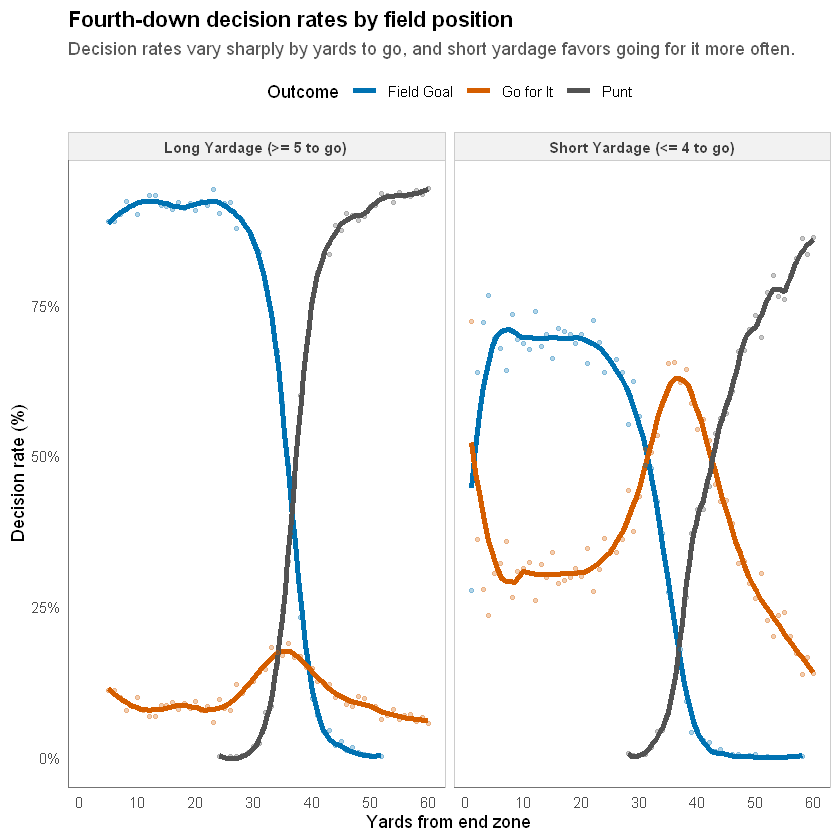

In [26]:
# --- 4th Down Decisions by Field Position & Yards-to-Go ---
decision_by_pos <- decision %>%
  filter(yardline_100 <= 60, yardline_100 >= 1) %>%
  mutate(
    ydsgap = if_else(ydstogo >= 5, "Long Yardage (>= 5 to go)", "Short Yardage (<= 4 to go)"),
    Outcome = dplyr::case_when(
      action == "FG" ~ "Field Goal",
      action == "punt" ~ "Punt",
      action == "go_for_it" ~ "Go for It"
    )
  ) %>%
  group_by(ydsgap, yardline_100, Outcome) %>%
  summarise(n = n(), .groups = "drop_last") %>%
  mutate(
    total_plays = sum(n),
    rate = n / total_plays
  ) %>%
  ungroup() %>%
  filter(total_plays > 20)

p_decision_pos <- ggplot(decision_by_pos, aes(x = yardline_100, y = rate, color = Outcome, fill = Outcome)) +
  geom_smooth(method = "loess", formula = y ~ x, span = 0.3, linewidth = 1.5, se = FALSE) +
  geom_point(alpha = 0.3, size = 1.2) +
  facet_wrap(~ ydsgap, ncol = 2) +
  scale_color_manual(values = c("Punt" = "#525252", "Field Goal" = "#0072B2", "Go for It" = "#D55E00")) +
  scale_fill_manual(values = c("Punt" = "#525252", "Field Goal" = "#0072B2", "Go for It" = "#D55E00")) +
  scale_y_continuous(labels = scales::percent) +
  scale_x_continuous(breaks = seq(0, 60, 10)) +
  labs(
    title = "Fourth-down decision rates by field position",
    subtitle = "Decision rates vary sharply by yards to go, and short yardage favors going for it more often.",
    x = "Yards from end zone",
    y = "Decision rate (%)"
  ) +
  theme_paper() +
  theme(legend.position = "top")
print(p_decision_pos)
save_fig(p_decision_pos, 'decision_by_field_position.png', w = 12, h = 6)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/kick_distance_distribution_15vs25.png



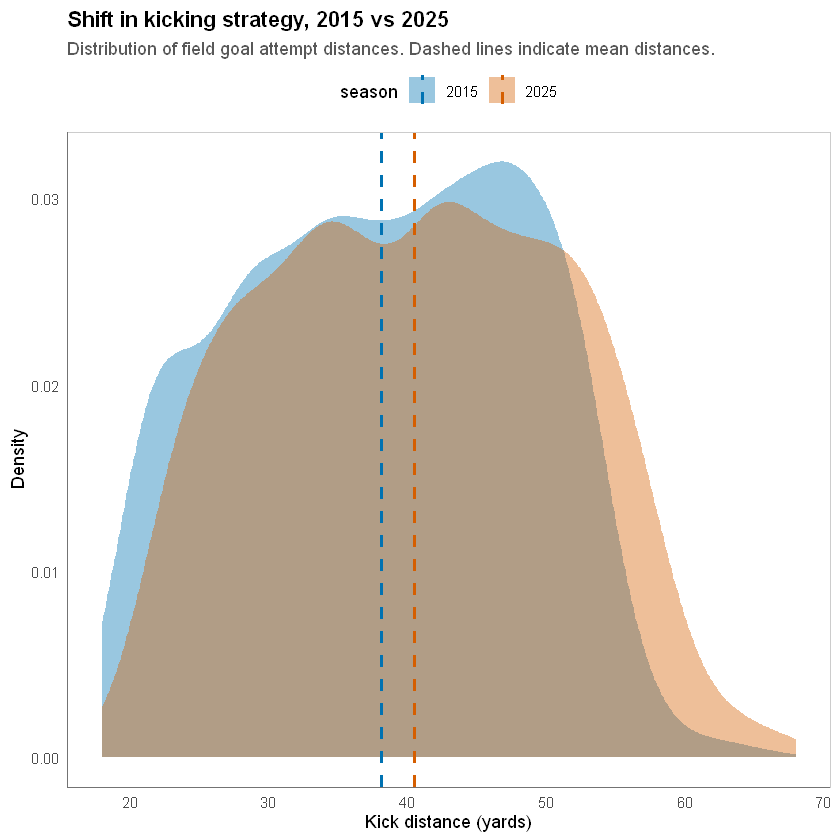

Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/kick_distance_distribution_pre_post_2020.png



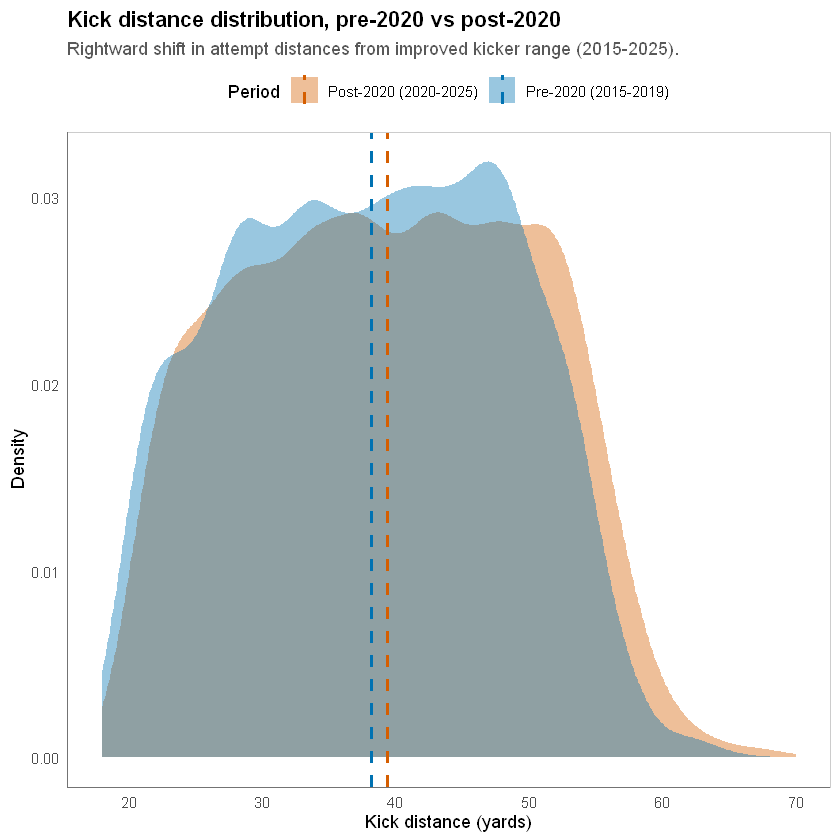

In [27]:
# --- Kick Distance Distribution: 2015 vs. 2025 ---
dist_comp_data <- fg_all %>%
  filter(
    play_type_original == 'field_goal',
    is_pat == 0,
    season %in% c(2015, 2025),
    !is.na(kick_distance)
  ) %>%
  mutate(season = factor(season))

season_means <- dist_comp_data %>%
  group_by(season) %>%
  summarise(mean_dist = mean(kick_distance), .groups = "drop")

p_dist_comp <- ggplot(dist_comp_data, aes(x = kick_distance, fill = season)) +
  geom_density(alpha = 0.4, color = NA) +
  geom_vline(data = season_means, aes(xintercept = mean_dist, color = season),
             linetype = "dashed", linewidth = 1, show.legend = TRUE) +
  scale_fill_manual(values = c("2015" = "#0072B2", "2025" = "#D55E00")) +
  scale_color_manual(values = c("2015" = "#0072B2", "2025" = "#D55E00")) +
  labs(
    title = "Shift in kicking strategy, 2015 vs 2025",
    subtitle = "Distribution of field goal attempt distances. Dashed lines indicate mean distances.",
    x = "Kick distance (yards)",
    y = "Density"
  ) +
  theme_paper() +
  theme(legend.position = "top")
print(p_dist_comp)
save_fig(p_dist_comp, 'kick_distance_distribution_15vs25.png', w = 10, h = 6)

# --- 2-Period Kick Distance Comparison: Pre-2020 vs Post-2020 (not shown in paper) ---
dist_2period <- fg_all %>%
  filter(
    play_type_original == 'field_goal',
    is_pat == 0,
    season >= 2015,
    !is.na(kick_distance)
  ) %>%
  mutate(
    Period = dplyr::case_when(
      season %in% 2015:2019 ~ "Pre-2020 (2015-2019)",
      season %in% 2020:2025 ~ "Post-2020 (2020-2025)",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(Period))

period_means_2 <- dist_2period %>%
  group_by(Period) %>%
  summarise(mean_dist = mean(kick_distance), .groups = "drop")

p_dist_2period <- ggplot(dist_2period, aes(x = kick_distance, fill = Period)) +
  geom_density(alpha = 0.4, color = NA) +
  geom_vline(data = period_means_2, aes(xintercept = mean_dist, color = Period),
             linetype = "dashed", linewidth = 0.9) +
  scale_fill_manual(values = c(
    "Pre-2020 (2015-2019)"  = "#0072B2",
    "Post-2020 (2020-2025)" = "#D55E00"
  )) +
  scale_color_manual(values = c(
    "Pre-2020 (2015-2019)"  = "#0072B2",
    "Post-2020 (2020-2025)" = "#D55E00"
  )) +
  labs(
    title = "Kick distance distribution, pre-2020 vs post-2020",
    subtitle = "Rightward shift in attempt distances from improved kicker range (2015-2025).",
    x = "Kick distance (yards)",
    y = "Density"
  ) +
  theme_paper() +
  theme(legend.position = "top")
print(p_dist_2period)
save_fig(p_dist_2period, 'kick_distance_distribution_pre_post_2020.png', w = 10, h = 6)


---

Warning message:
"Removed 7 rows containing missing values or values outside the scale range
(`geom_smooth()`)."


Warning message:
"Removed 7 rows containing missing values or values outside the scale range
(`geom_smooth()`)."


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/make_rate_by_distance_era.png



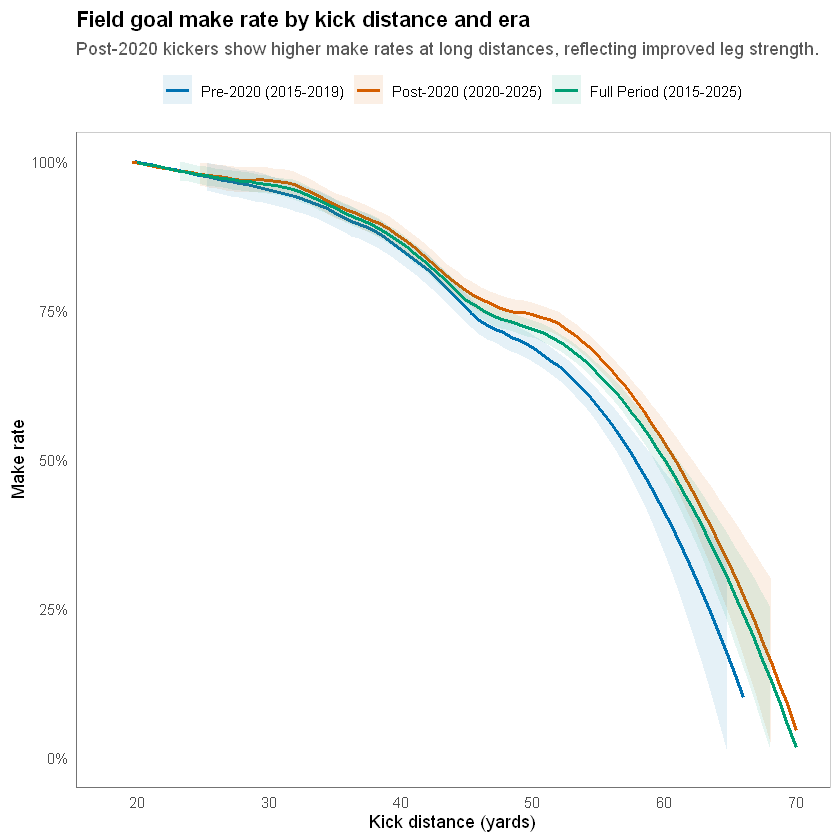

In [28]:
# --- Make rate by Kick Distance: Era Comparison ---
fg_era_data <- fg_all %>%
  filter(play_type_original == 'field_goal', is_pat == 0,
         season >= 2015, !is.na(kick_distance), !is.na(kick_made))

make_rate_plot_data <- bind_rows(
  fg_era_data %>% filter(season %in% 2015:2019) %>% mutate(Era = "Pre-2020 (2015-2019)"),
  fg_era_data %>% filter(season %in% 2020:2025) %>% mutate(Era = "Post-2020 (2020-2025)"),
  fg_era_data                                    %>% mutate(Era = "Full Period (2015-2025)")
) %>%
  mutate(Era = factor(Era, levels = c(
    "Pre-2020 (2015-2019)", "Post-2020 (2020-2025)", "Full Period (2015-2025)"
  )))

p_make_rate_era <- ggplot(make_rate_plot_data,
    aes(x = kick_distance, y = kick_made, color = Era, fill = Era)) +
  geom_smooth(method = 'loess', formula = y ~ x, span = 0.4,
              se = TRUE, alpha = 0.10, linewidth = 1.1) +
  scale_color_manual(values = c(
    "Pre-2020 (2015-2019)"    = "#0072B2",
    "Post-2020 (2020-2025)"   = "#D55E00",
    "Full Period (2015-2025)" = "#009E73"
  )) +
  scale_fill_manual(values = c(
    "Pre-2020 (2015-2019)"    = "#0072B2",
    "Post-2020 (2020-2025)"   = "#D55E00",
    "Full Period (2015-2025)" = "#009E73"
  )) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
  labs(
    title = "Field goal make rate by kick distance and era",
    subtitle = "Post-2020 kickers show higher make rates at long distances, reflecting improved leg strength.",
    x = "Kick distance (yards)",
    y = "Make rate",
    color = NULL, fill = NULL
  ) +
  theme_paper() +
  theme(legend.position = "top")
print(p_make_rate_era)
save_fig(p_make_rate_era, 'make_rate_by_distance_era.png', w = 10, h = 6)


---

Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/short_yardage_decisions_era.png



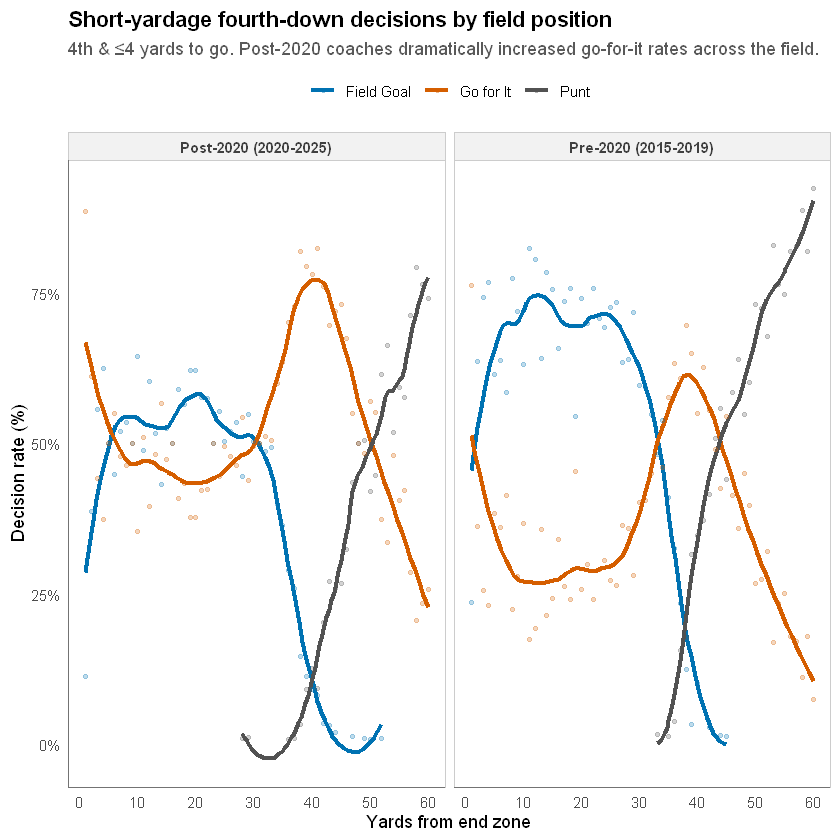

In [29]:
# --- Short-yardage fourth-down decisions by field position: Pre-2020 vs Post-2020 ---
short_ytg_era <- decision %>%
  filter(ydstogo <= 4, yardline_100 <= 60, yardline_100 >= 1,
         season >= 2015) %>%
  mutate(
    Era = dplyr::case_when(
      season %in% 2015:2019 ~ "Pre-2020 (2015-2019)",
      season %in% 2020:2025 ~ "Post-2020 (2020-2025)",
      TRUE ~ NA_character_
    ),
    Outcome = dplyr::case_when(
      action == "FG"        ~ "Field Goal",
      action == "punt"      ~ "Punt",
      action == "go_for_it" ~ "Go for It"
    )
  ) %>%
  filter(!is.na(Era)) %>%
  group_by(Era, yardline_100, Outcome) %>%
  summarise(n = n(), .groups = "drop_last") %>%
  mutate(total_plays = sum(n), rate = n / total_plays) %>%
  ungroup() %>%
  filter(total_plays > 10)

p_short_ytg_era <- ggplot(short_ytg_era,
    aes(x = yardline_100, y = rate, color = Outcome, fill = Outcome)) +
  geom_smooth(method = "loess", formula = y ~ x, span = 0.4,
              linewidth = 1.3, se = FALSE) +
  geom_point(alpha = 0.25, size = 1.0) +
  facet_wrap(~ Era, ncol = 2) +
  scale_color_manual(values = c(
    "Punt"       = "#525252",
    "Field Goal" = "#0072B2",
    "Go for It"  = "#D55E00"
  )) +
  scale_fill_manual(values = c(
    "Punt"       = "#525252",
    "Field Goal" = "#0072B2",
    "Go for It"  = "#D55E00"
  )) +
  scale_y_continuous(labels = scales::percent) +
  scale_x_continuous(breaks = seq(0, 60, 10)) +
  labs(
    title = "Short-yardage fourth-down decisions by field position",
    subtitle = "4th & \u22644 yards to go. Post-2020 coaches dramatically increased go-for-it rates across the field.",
    x = "Yards from end zone",
    y = "Decision rate (%)",
    color = NULL, fill = NULL
  ) +
  theme_paper() +
  theme(legend.position = "top")
print(p_short_ytg_era)
save_fig(p_short_ytg_era, 'short_yardage_decisions_era.png', w = 12, h = 6)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/wpa_landscape_by_era.png



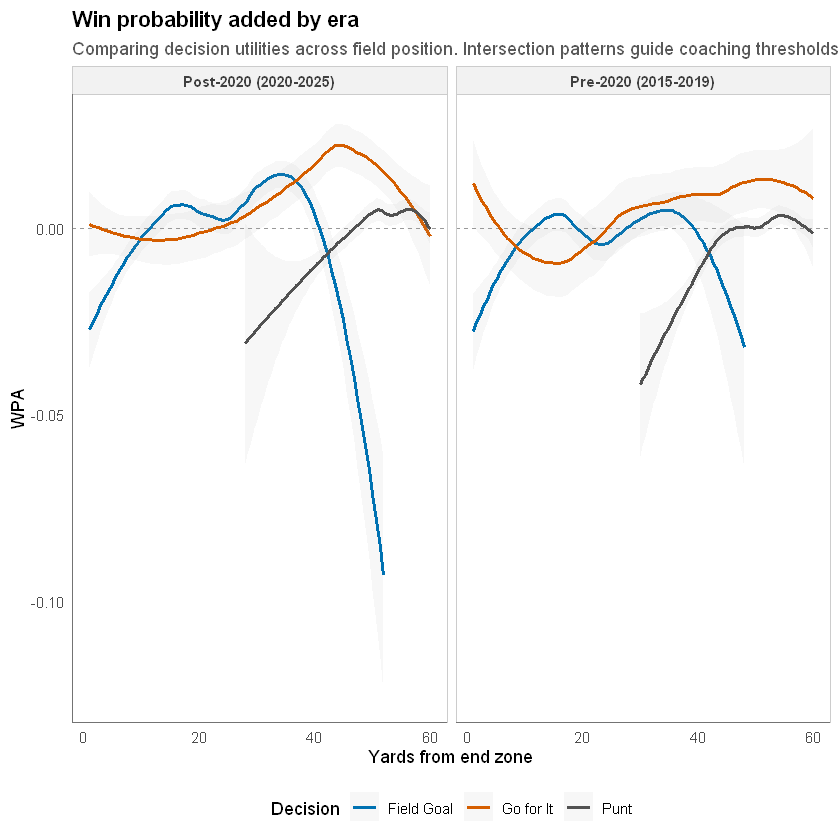

In [30]:
# --- WPA Landscape by Era (Yards from end zone) ---
wpa_data <- decision %>%
  filter(!is.na(wpa), !is.na(yardline_100)) %>%
  filter(yardline_100 <= 60, yardline_100 >= 1) %>%
  mutate(
    Decision = case_when(
      action == "FG" ~ "Field Goal",
      action == "punt" ~ "Punt",
      action == "go_for_it" ~ "Go for It",
      TRUE ~ NA_character_
    ),
    Era = case_when(
      season %in% 2015:2019 ~ "Pre-2020 (2015-2019)",
      season %in% 2020:2025 ~ "Post-2020 (2020-2025)",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(Decision), !is.na(Era))

wpa_summary <- wpa_data %>%
  group_by(Decision, yardline_100, Era) %>%
  summarise(
    n = n(),
    mean_wpa = mean(wpa, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(n > 5)

p_wpa_era <- ggplot(wpa_data, aes(x = yardline_100, y = wpa, color = Decision)) +
  geom_hline(yintercept = 0, colour = 'grey60', lty = 2) +
  geom_smooth(method = 'loess', formula = y ~ x, se = TRUE, alpha = 0.08, span = 0.6, linewidth = 1.0) +
  facet_wrap(~ Era, ncol = 2) +
  scale_colour_manual(values = c('Field Goal' = '#0072B2', 'Punt' = '#525252', 'Go for It' = '#D55E00')) +
  labs(
    title = 'Win probability added by era',
    subtitle = 'Comparing decision utilities across field position. Intersection patterns guide coaching thresholds.',
    x = 'Yards from end zone',
    y = 'WPA',
    color = 'Decision'
  ) +
  theme_paper()
print(p_wpa_era)
save_fig(p_wpa_era, 'wpa_landscape_by_era.png', w = 11, h = 5)


Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/wpa_by_ytg_regime.png



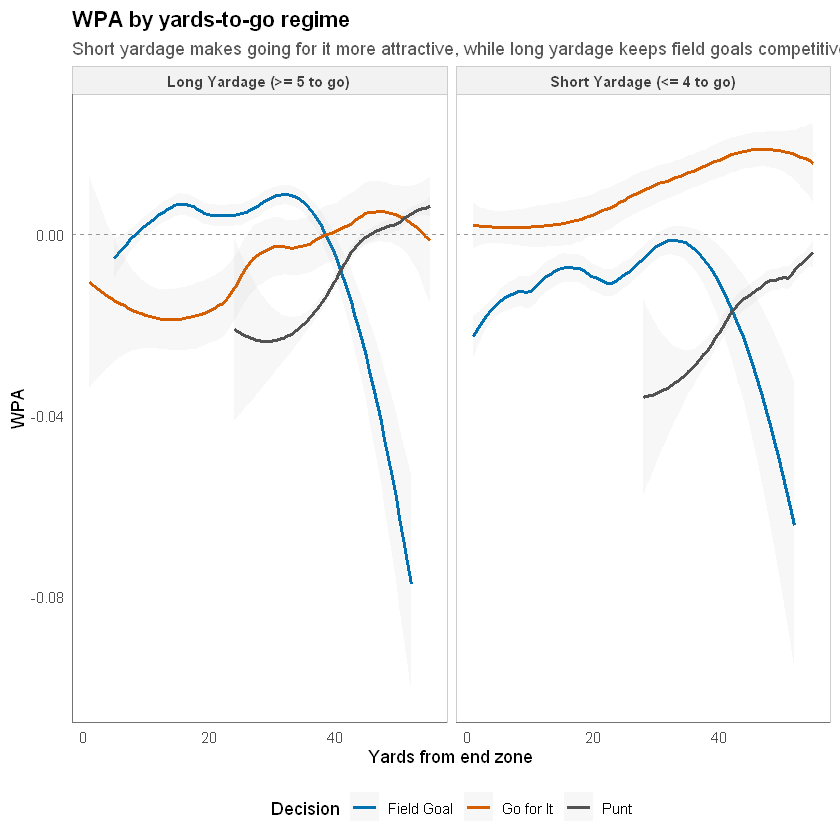

In [31]:
# --- WPA by yards-to-go regime ---
wpa_ytg_data <- decision %>%
  filter(!is.na(wpa), !is.na(yardline_100)) %>%
  filter(yardline_100 <= 55, yardline_100 >= 1) %>%
  mutate(
    Decision = case_when(
      action == "FG" ~ "Field Goal",
      action == "punt" ~ "Punt",
      action == "go_for_it" ~ "Go for It",
      TRUE ~ NA_character_
    ),
    ytg_regime = if_else(ydstogo >= 5, "Long Yardage (>= 5 to go)", "Short Yardage (<= 4 to go)")
  ) %>%
  filter(!is.na(Decision))

p_wpa_ytg <- ggplot(wpa_ytg_data, aes(x = yardline_100, y = wpa, color = Decision)) +
  geom_hline(yintercept = 0, colour = 'grey60', lty = 2) +
  geom_smooth(method = 'loess', formula = y ~ x, se = TRUE, alpha = 0.08, span = 0.6, linewidth = 1.0) +
  facet_wrap(~ ytg_regime, ncol = 2) +
  scale_colour_manual(values = c('Field Goal' = '#0072B2', 'Punt' = '#525252', 'Go for It' = '#D55E00')) +
  labs(
    title = 'WPA by yards-to-go regime',
    subtitle = 'Short yardage makes going for it more attractive, while long yardage keeps field goals competitive.',
    x = 'Yards from end zone',
    y = 'WPA',
    color = 'Decision'
  ) +
  theme_paper()
print(p_wpa_ytg)
save_fig(p_wpa_ytg, 'wpa_by_ytg_regime.png', w = 12, h = 5.5)


---

Saved: X:/My Files/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/reports/figures/kick_density_on_wpa.png



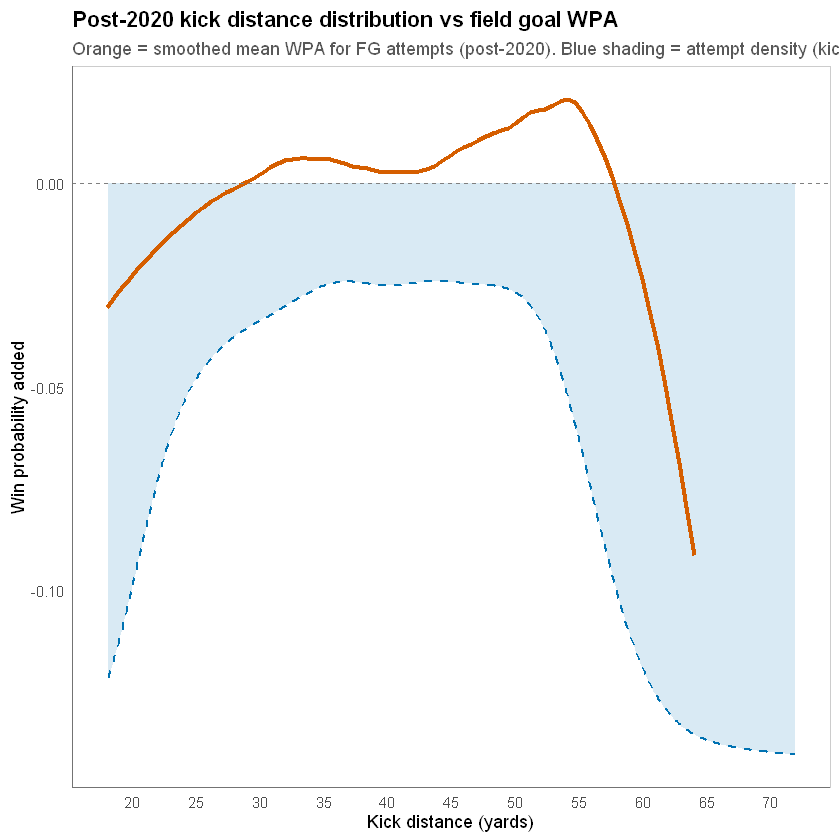

In [32]:
# --- Post-2020 Kick Density Overlaid on WPA Curve (Field Goal) ---
# Build post-2020 FG WPA data on kick_distance scale
wpa_fg_post2020 <- decision %>%
  filter(
    action == "FG",
    season %in% 2020:2025,
    !is.na(wpa), !is.na(yardline_100),
    yardline_100 >= 1, yardline_100 <= 55
  ) %>%
  mutate(kick_distance = yardline_100 + 17) %>%
  group_by(kick_distance) %>%
  summarise(mean_wpa = mean(wpa, na.rm = TRUE), n = n(), .groups = "drop") %>%
  filter(n > 5)

# Post-2020 kick density
post2020_kicks <- fg_all %>%
  filter(play_type_original == 'field_goal', is_pat == 0,
         season %in% 2020:2025, !is.na(kick_distance),
         kick_distance >= 18, kick_distance <= 72)

density_vals <- density(post2020_kicks$kick_distance, bw = 2.5, n = 512)
density_df <- data.frame(
  kick_distance = density_vals$x,
  dens = density_vals$y
) %>%
  filter(kick_distance >= 18, kick_distance <= 72)

# Scale density to WPA range for dual overlay
wpa_range <- range(wpa_fg_post2020$mean_wpa, na.rm = TRUE)
dens_range <- range(density_df$dens)
density_df <- density_df %>%
  mutate(dens_scaled = (dens - dens_range[1]) / (dens_range[2] - dens_range[1]) *
         (wpa_range[2] - wpa_range[1]) * 0.6 + wpa_range[1])

p_density_wpa <- ggplot() +
  geom_area(data = density_df,
            aes(x = kick_distance, y = dens_scaled),
            fill = "#0072B2", alpha = 0.15, color = NA) +
  geom_line(data = density_df,
            aes(x = kick_distance, y = dens_scaled),
            color = "#0072B2", linewidth = 0.8, linetype = "dashed") +
  geom_smooth(data = wpa_fg_post2020,
              aes(x = kick_distance, y = mean_wpa),
              method = "loess", formula = y ~ x, span = 0.5,
              color = "#D55E00", linewidth = 1.4, se = FALSE) +
  geom_hline(yintercept = 0, color = "grey50", lty = 2) +
  scale_x_continuous(breaks = seq(20, 70, 5), limits = c(18, 72)) +
  labs(
    title = "Post-2020 kick distance distribution vs field goal WPA",
    subtitle = "Orange = smoothed mean WPA for FG attempts (post-2020). Blue shading = attempt density (kick distance scale).",
    x = "Kick distance (yards)",
    y = "Win probability added"
  ) +
  theme_paper()
print(p_density_wpa)
save_fig(p_density_wpa, 'kick_density_on_wpa.png', w = 10, h = 6)
